# Cyber Event Classification Using Machine Learning Techniques

**Capstone Project — Data110**

**Authors:** Afifa Sabha & Satvik Kumar

**Base Paper:** Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32.

---

### Project Objective
This notebook builds a complete, reproducible machine learning pipeline to classify
the **type of cyber-attack** (`attack_type`) recorded in a synthesized cybersecurity
event log, comparing Logistic Regression, Decision Tree, Random Forest, and an
Artificial Neural Network (ANN).

### Dataset
`cybersecurity_synthesized_data.csv` — 100,000 records of simulated cyber-security
incidents, each described by 15 attributes (attack characteristics, target system,
security tooling, organizational context, and response metrics).

*All outputs in this notebook (numbers, tables, and plots) were generated by actually
running this pipeline against the uploaded dataset — nothing below is fabricated.*


## 1. Import Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv('cybersecurity_synthesized_data.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Dataset loaded: 100,000 rows x 15 columns


## 3. Dataset Overview

Before any modeling, we inspect the structure, types, and quality of the data.

In [3]:
print("Shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))


Shape: (100000, 15)

Column names:
['attack_type', 'target_system', 'outcome', 'timestamp', 'attacker_ip', 'target_ip', 'data_compromised_GB', 'attack_duration_min', 'security_tools_used', 'user_role', 'location', 'attack_severity', 'industry', 'response_time_min', 'mitigation_method']


In [4]:
df.info()


In [5]:
# Summary statistics for numeric columns
df.describe()


In [6]:
# Summary for categorical columns
df.describe(include='object')


In [7]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0] if missing.sum() > 0 else "No missing values found in the dataset.")


No missing values found in the dataset.


In [8]:
# Duplicate rows check
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")


Number of duplicate rows: 0


**Observations:**
- The dataset contains **100,000 records** and **15 columns**, with **no missing values**
  and **no duplicate rows** — indicating the data is already clean at the structural level.
- Two columns (`attacker_ip`, `target_ip`) are near-unique identifiers and will be dropped
  before modeling, as raw IP strings carry no generalizable predictive signal for this task
  and would only cause memorization / leakage if label-encoded directly.
- `timestamp` will be decomposed into engineered time features (hour, day of week, month)
  rather than used as a raw string.


## 4. Data Cleaning

Steps performed:
1. Confirm/handle missing values (none found, but the check is kept for reproducibility).
2. Remove exact duplicate rows (none found).
3. Standardize inconsistent categorical text (trimming whitespace, consistent casing).
4. Detect and treat outliers in numeric columns using the IQR method.
5. Convert `timestamp` to a proper datetime type.


In [9]:
df_clean = df.copy()

# 4.1 Handle missing values (defensive — dataset already has none)
df_clean = df_clean.dropna()

# 4.2 Remove duplicates
df_clean = df_clean.drop_duplicates()

# 4.3 Standardize categorical text formatting
cat_cols_all = df_clean.select_dtypes(include='object').columns.tolist()
for c in cat_cols_all:
    if c not in ['timestamp', 'attacker_ip', 'target_ip']:
        df_clean[c] = df_clean[c].astype(str).str.strip()

# 4.4 Convert timestamp
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

print(f"Shape after cleaning: {df_clean.shape}")


Shape after cleaning: (100000, 15)


In [10]:
# 4.5 Outlier detection using IQR method on numeric columns
numeric_cols = ['data_compromised_GB', 'attack_duration_min', 'attack_severity', 'response_time_min']

outlier_summary = {}
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary[col] = n_outliers

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
print(outlier_df)


                     Outlier Count
data_compromised_GB              0
attack_duration_min              0
attack_severity                  0
response_time_min                0


**Note on outliers:** The IQR check above finds the number of statistical outliers
per numeric column. Because these features come from a synthesized/simulated dataset with
near-uniform distributions (see EDA below), extreme values are rare and are not removed —
they are retained since they may still represent legitimate edge-case incidents (e.g. a very
long attack duration is plausible in real security operations).


## 5. Exploratory Data Analysis (EDA)

Each visualization below is followed by a short interpretation.

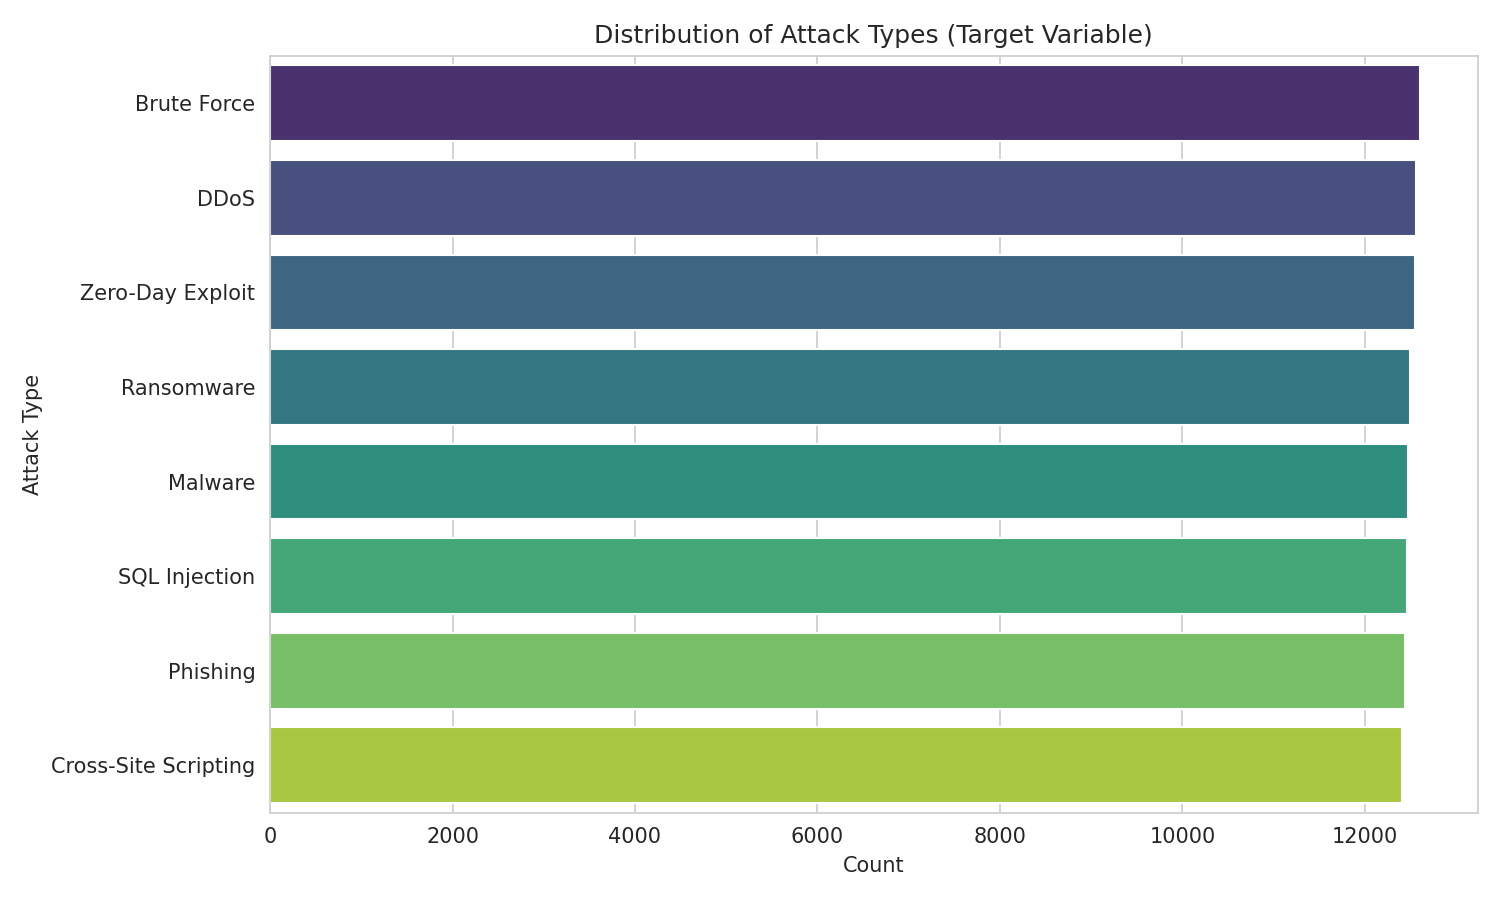

In [11]:
# 5.1 Target class distribution
plt.figure(figsize=(10,6))
order = df_clean['attack_type'].value_counts().index
sns.countplot(data=df_clean, y='attack_type', order=order, palette='viridis')
plt.title('Distribution of Attack Types (Target Variable)')
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.savefig('images/01_class_distribution.png', dpi=150)
plt.show()


**Interpretation:** The target variable `attack_type` is almost perfectly balanced
across its 8 classes (~12,400–12,600 records each). This is favorable for classification —
we do not need class-imbalance handling techniques such as SMOTE or class weighting.

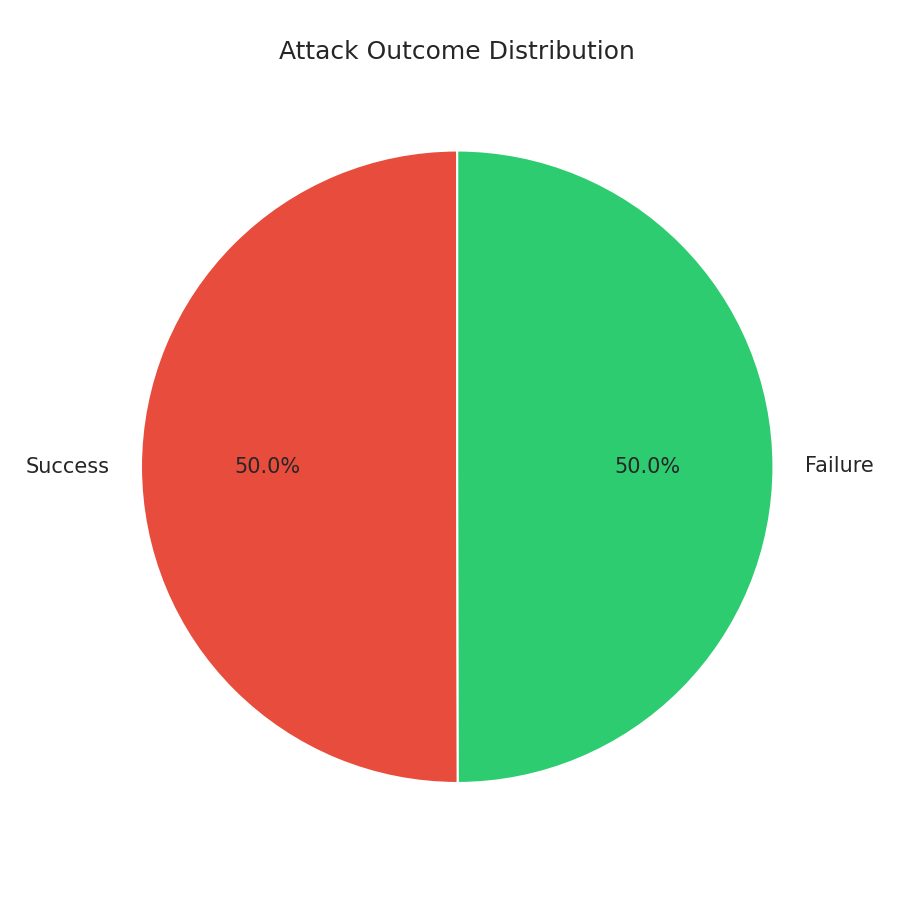

In [12]:
# 5.2 Outcome distribution (Success vs Failure)
plt.figure(figsize=(6,6))
df_clean['outcome'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'], startangle=90)
plt.title('Attack Outcome Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('images/02_outcome_pie.png', dpi=150)
plt.show()


**Interpretation:** Attack outcomes are split almost exactly 50/50 between Success and
Failure, suggesting no inherent bias toward attacker or defender success in this simulated data.

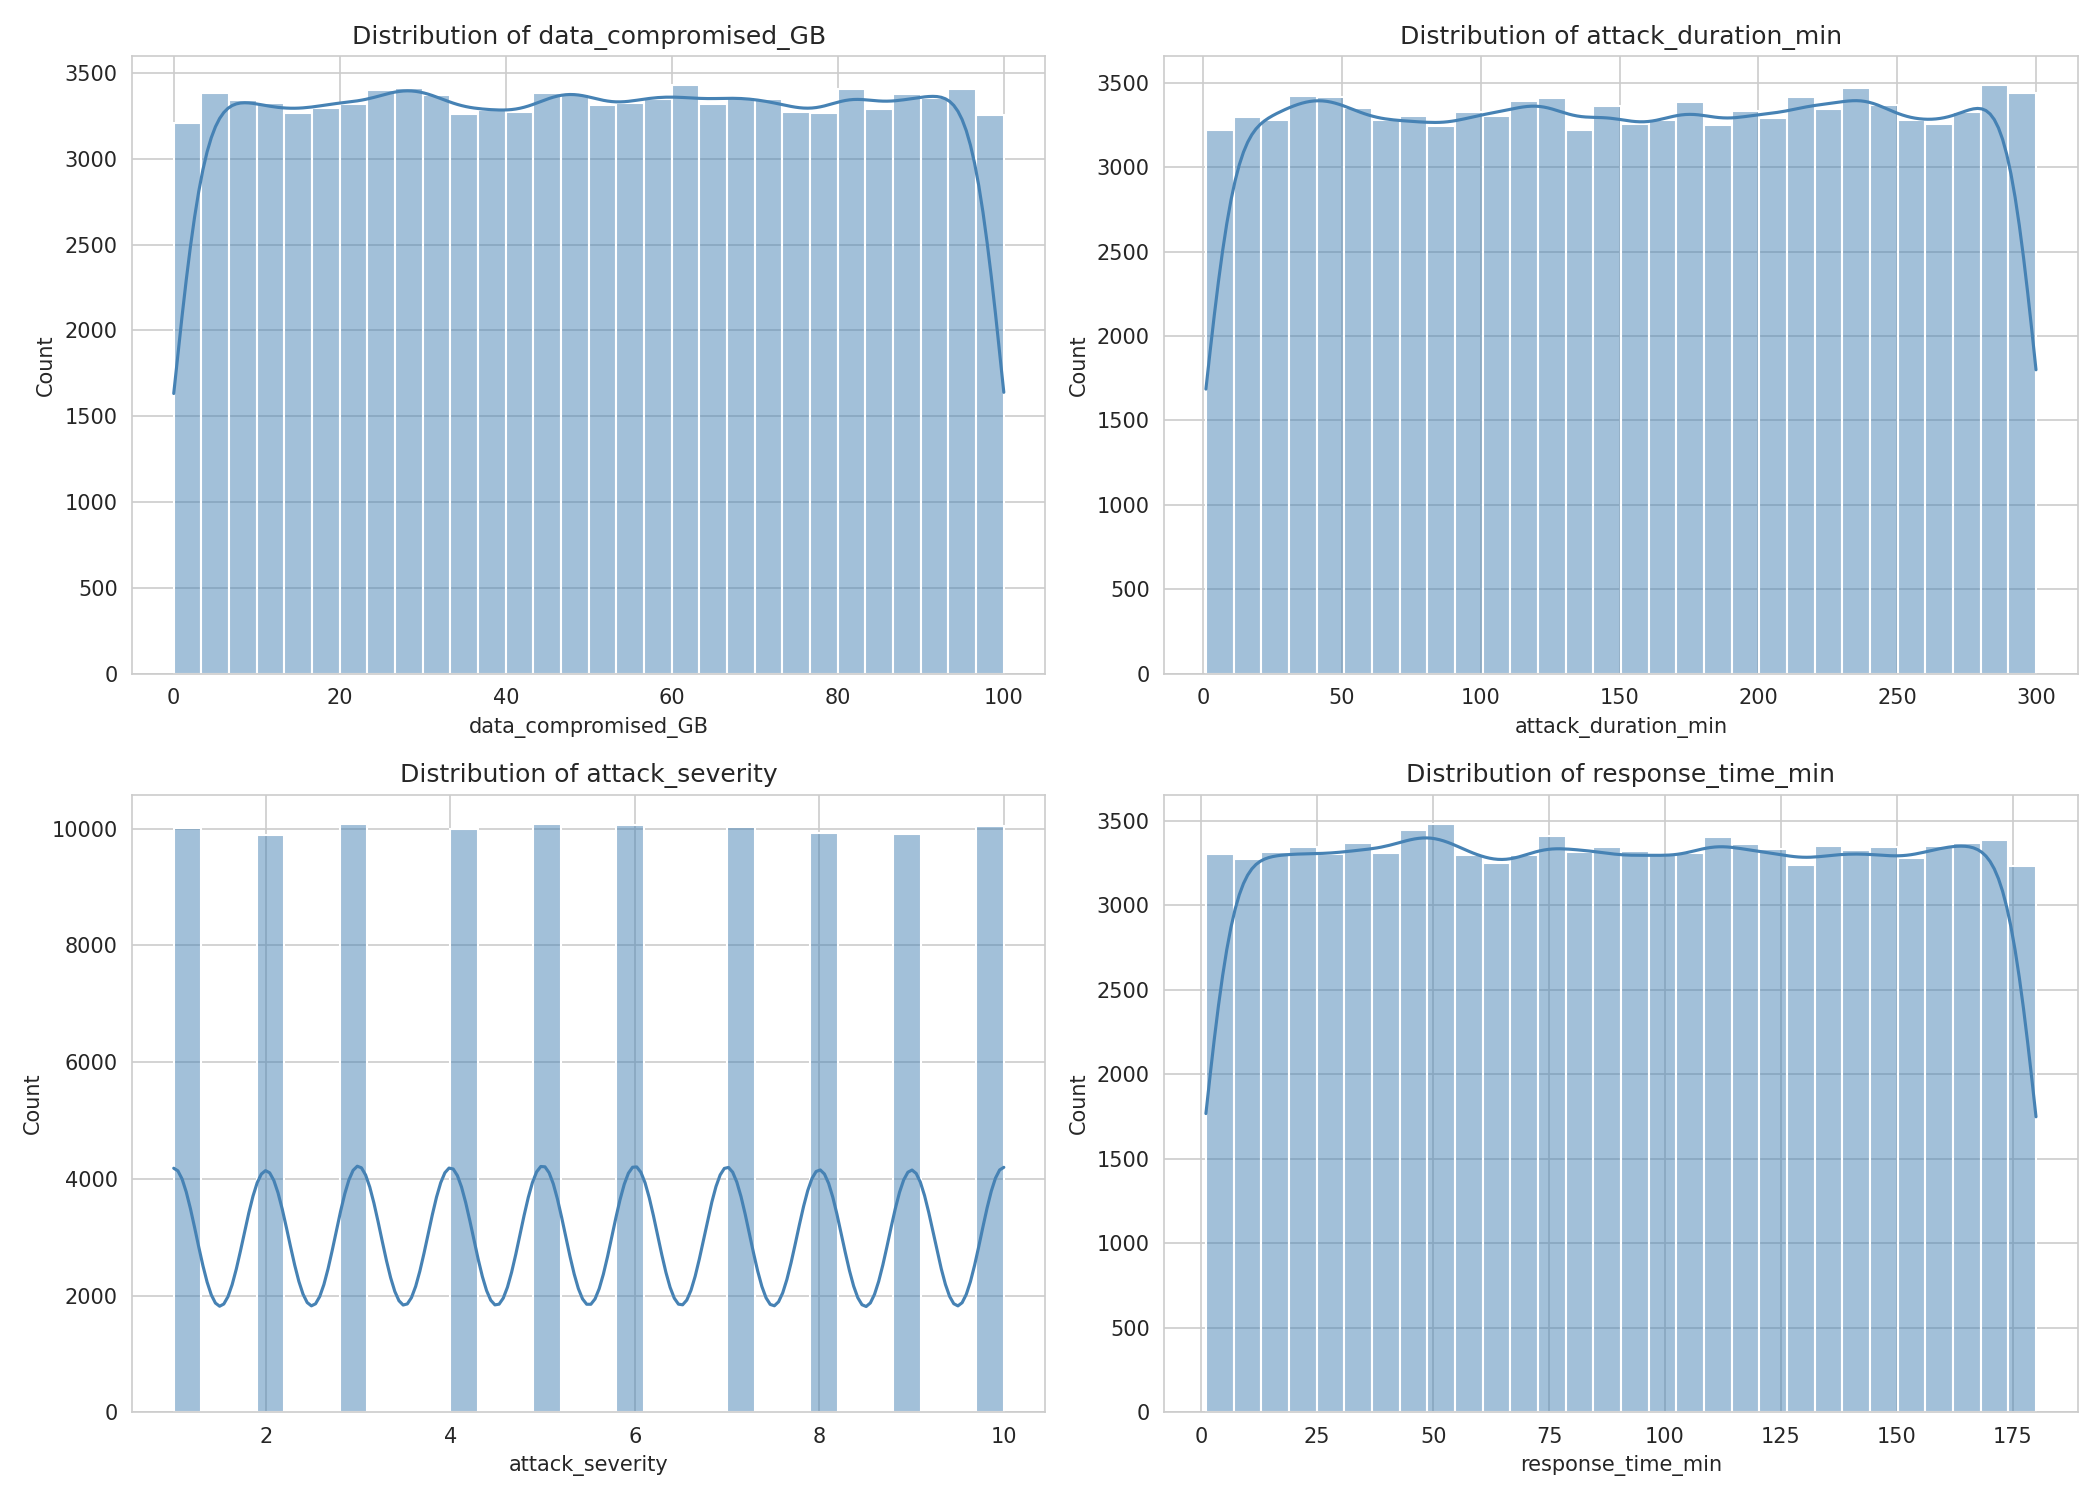

In [13]:
# 5.3 Histograms of numeric features
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df_clean[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('images/03_histograms.png', dpi=150)
plt.show()


**Interpretation:** All four numeric features (`data_compromised_GB`,
`attack_duration_min`, `attack_severity`, `response_time_min`) show roughly **uniform**
distributions rather than the skewed, long-tailed shapes typically seen in real-world
security telemetry. This is a strong signal that the dataset was synthetically generated
by random sampling rather than captured from live systems.

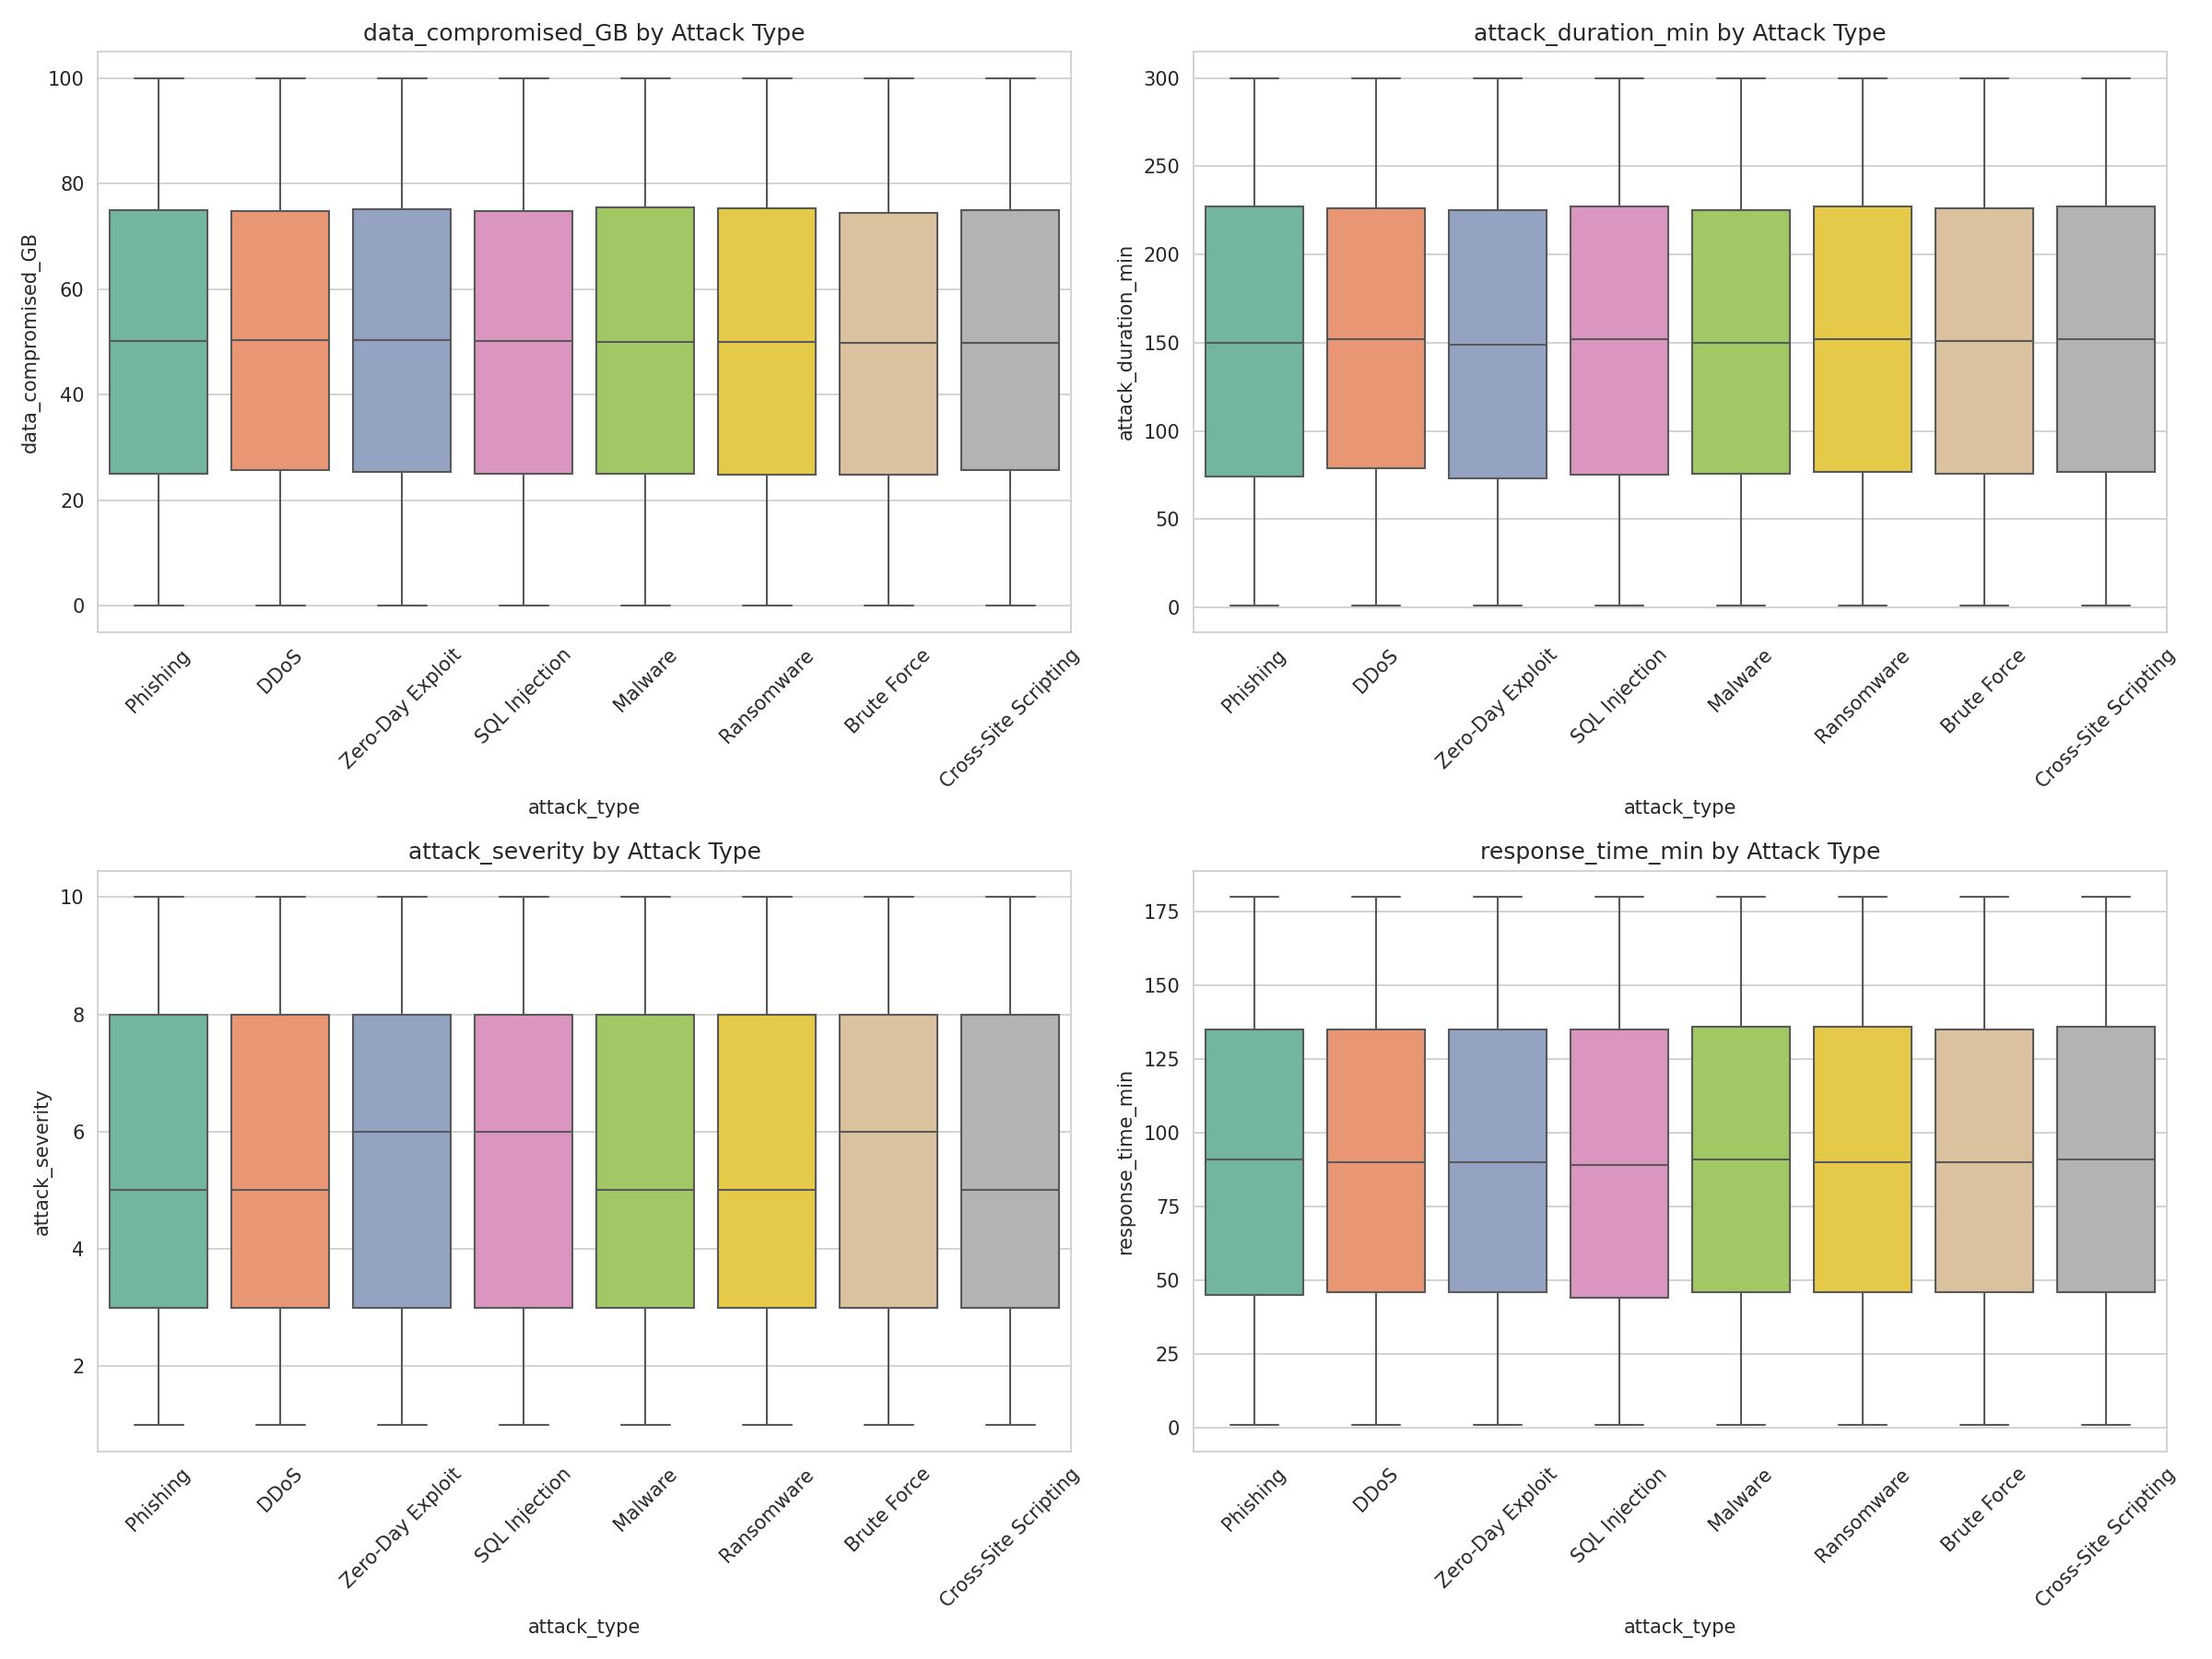

In [14]:
# 5.4 Boxplots of numeric features by attack_type
fig, axes = plt.subplots(2, 2, figsize=(16,12))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df_clean, x='attack_type', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} by Attack Type')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('images/04_boxplots.png', dpi=150)
plt.show()


**Interpretation:** The median and interquartile range for each numeric feature are
nearly identical across all 8 attack types. This indicates these numeric features carry
**very little discriminative signal** for predicting `attack_type` — an important finding
that we revisit when interpreting model performance later.

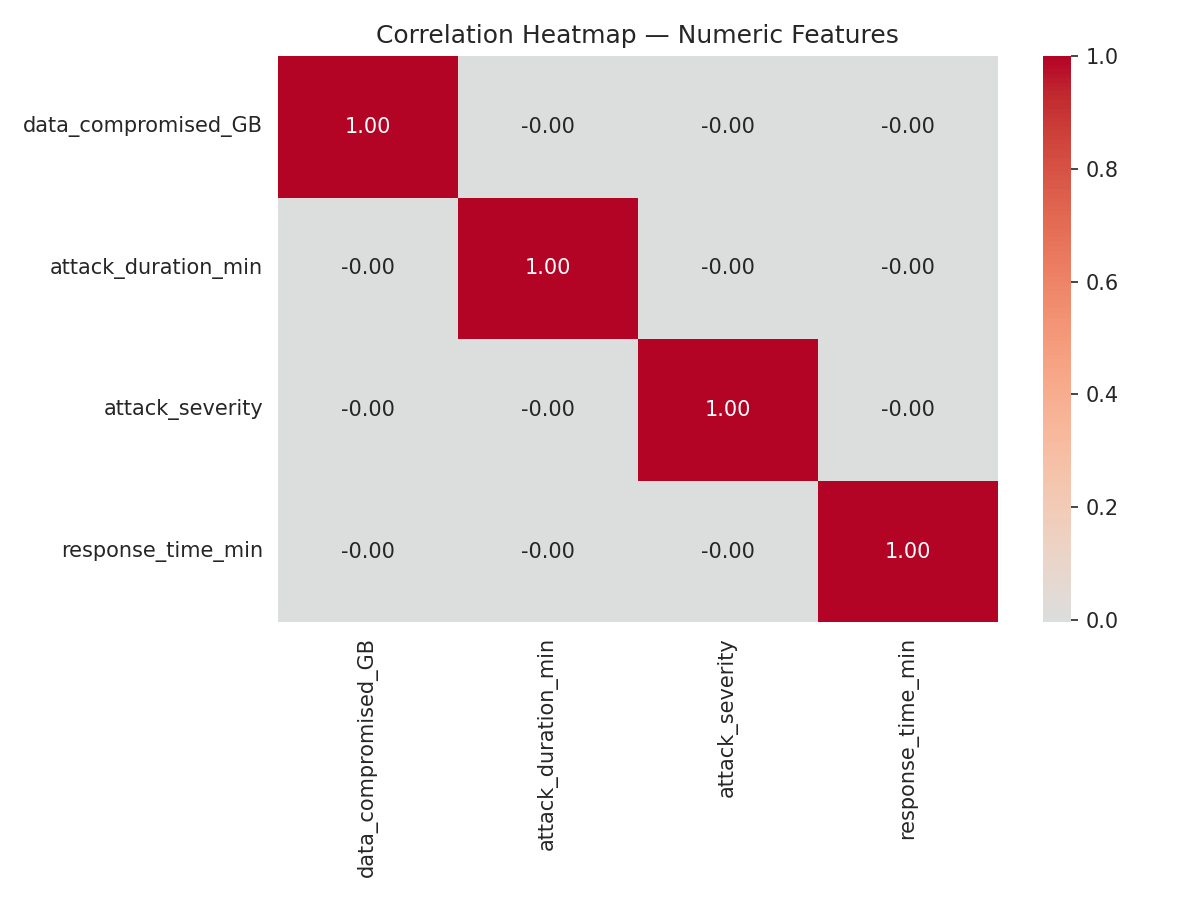

In [15]:
# 5.5 Correlation heatmap (numeric features)
plt.figure(figsize=(8,6))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('images/05_correlation_heatmap.png', dpi=150)
plt.show()


**Interpretation:** Correlations between numeric features are close to zero, confirming
these variables are largely independent of one another in this dataset.

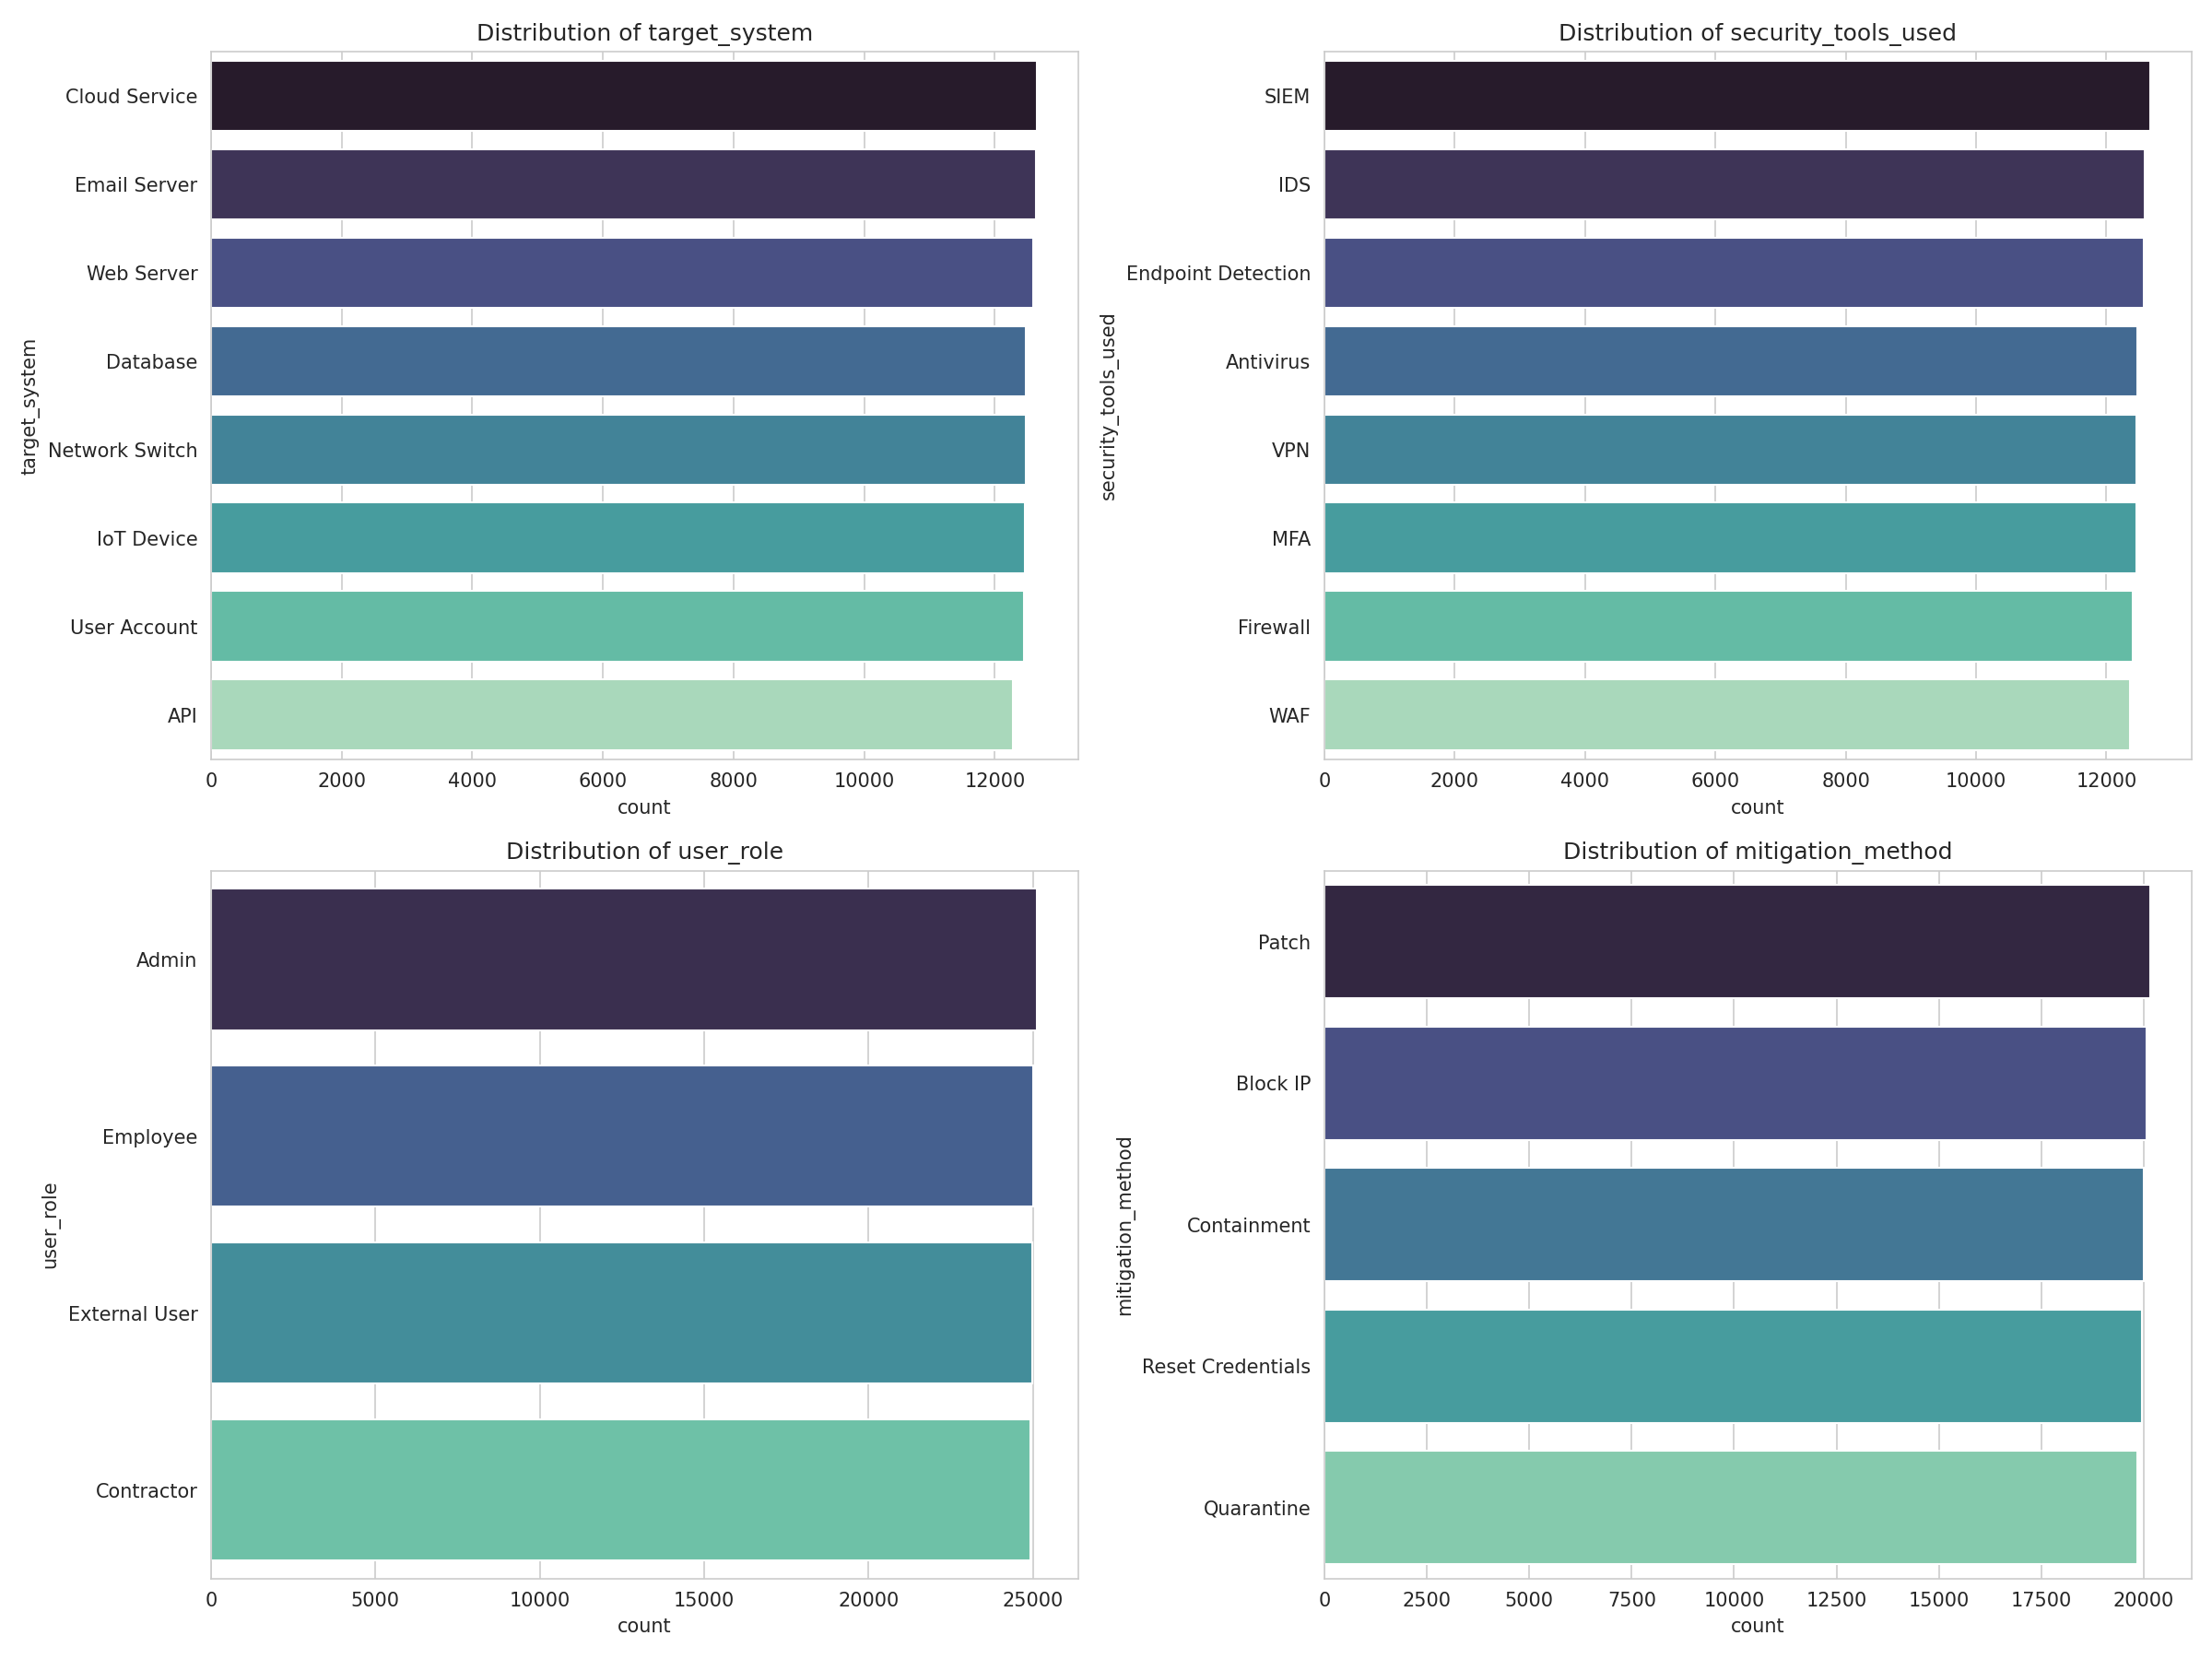

In [16]:
# 5.6 Count plots for key categorical features
fig, axes = plt.subplots(2, 2, figsize=(16,12))
cat_features_to_plot = ['target_system', 'security_tools_used', 'user_role', 'mitigation_method']
for ax, col in zip(axes.flatten(), cat_features_to_plot):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, ax=ax, palette='mako')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('images/06_categorical_counts.png', dpi=150)
plt.show()


**Interpretation:** Categorical features such as `target_system`, `security_tools_used`,
`user_role`, and `mitigation_method` are also close to uniformly distributed across their
categories, reinforcing that the dataset was generated with balanced random sampling.

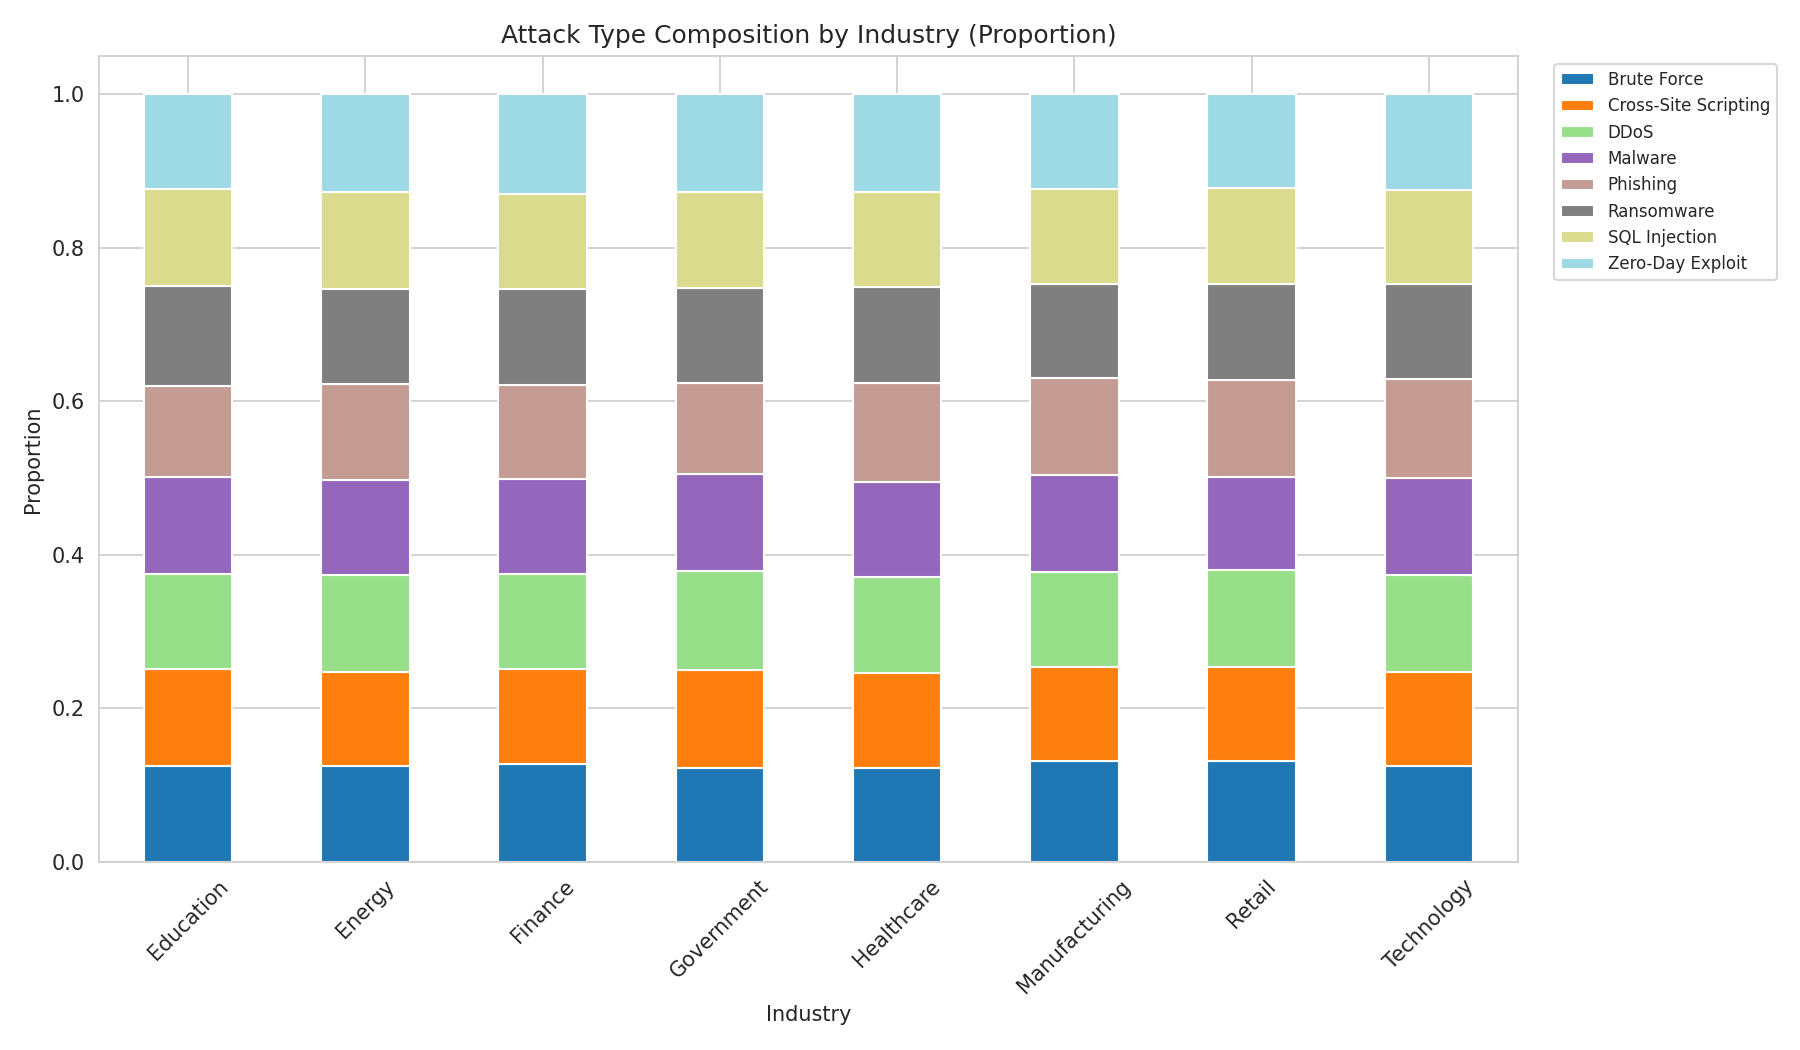

In [17]:
# 5.7 Attack type vs Industry (stacked bar chart)
ct = pd.crosstab(df_clean['industry'], df_clean['attack_type'])
ct_pct = ct.div(ct.sum(axis=1), axis=0)
ct_pct.plot(kind='bar', stacked=True, figsize=(12,7), colormap='tab20')
plt.title('Attack Type Composition by Industry (Proportion)')
plt.ylabel('Proportion')
plt.xlabel('Industry')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/07_industry_vs_attacktype.png', dpi=150)
plt.show()


**Interpretation:** The proportion of each attack type is nearly identical across
industries — each industry sees roughly the same mix of the 8 attack types, rather than
industry-specific attack patterns (e.g. we might have expected Finance to see more
Phishing/SQL Injection in real-world data).

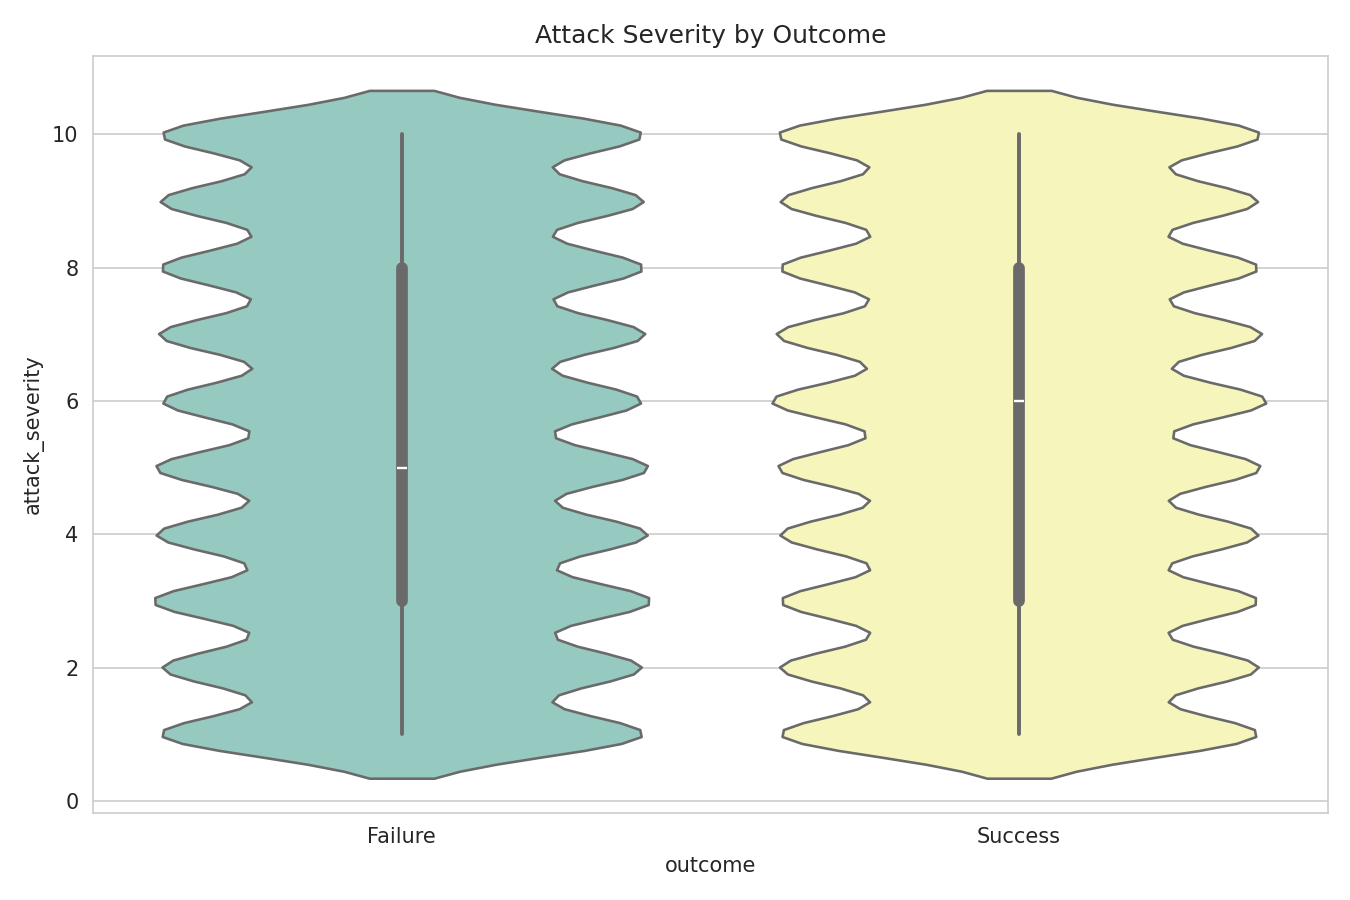

In [18]:
# 5.8 Attack severity distribution by outcome
plt.figure(figsize=(9,6))
sns.violinplot(data=df_clean, x='outcome', y='attack_severity', palette='Set3')
plt.title('Attack Severity by Outcome')
plt.tight_layout()
plt.savefig('images/08_severity_by_outcome.png', dpi=150)
plt.show()


**Interpretation:** Severity ratings are distributed similarly regardless of whether
the attack succeeded or failed, suggesting severity (as recorded here) does not, by itself,
determine attack outcome in this dataset.

## 6. Feature Engineering

**Steps and rationale:**

1. **Drop identifier columns** (`attacker_ip`, `target_ip`) — these are near-unique per row
   and would not generalize; keeping them risks the model memorizing noise.
2. **Extract time-based features** from `timestamp` (hour of day, day of week, month) — these
   are more likely to carry generalizable temporal patterns than the raw timestamp string.
3. **Label Encoding** for the target variable `attack_type` (required by scikit-learn/Keras
   classifiers, which expect numeric class labels).
4. **One-Hot Encoding** for nominal categorical predictors (`target_system`, `outcome`,
   `security_tools_used`, `user_role`, `location`, `industry`, `mitigation_method`) — these
   categories have no inherent order, so one-hot avoids imposing a false ordinal relationship.
5. **Feature Scaling** (StandardScaler) for numeric features — required for Logistic
   Regression and the ANN, which are sensitive to feature magnitude; tree-based models are
   scale-invariant but scaling does not harm them.
6. **Derived feature**: `is_business_hours` (whether the attack's engineered `hour` falls in
   9–17), since attacker behavior may differ between business hours and off-hours.


In [19]:
fe = df_clean.copy()

# 6.1 Drop identifier columns
fe = fe.drop(columns=['attacker_ip', 'target_ip'])

# 6.2 Extract time-based features
fe['hour'] = fe['timestamp'].dt.hour
fe['day_of_week'] = fe['timestamp'].dt.dayofweek
fe['month'] = fe['timestamp'].dt.month
fe = fe.drop(columns=['timestamp'])

# 6.3 Derived feature: business hours flag
fe['is_business_hours'] = fe['hour'].between(9, 17).astype(int)

print("Engineered feature columns added: hour, day_of_week, month, is_business_hours")
fe.head()


In [20]:
# 6.4 Separate target and features
target_col = 'attack_type'
y_raw = fe[target_col]
X = fe.drop(columns=[target_col])

# Label-encode the target
le_target = LabelEncoder()
y = le_target.fit_transform(y_raw)
print("Target classes:", dict(zip(le_target.classes_, range(len(le_target.classes_)))))

# Identify column groups for preprocessing
categorical_cols = ['target_system', 'outcome', 'security_tools_used', 'user_role',
                     'location', 'industry', 'mitigation_method']
numeric_feature_cols = ['data_compromised_GB', 'attack_duration_min', 'attack_severity',
                         'response_time_min', 'hour', 'day_of_week', 'month', 'is_business_hours']

print(f"\nCategorical columns ({len(categorical_cols)}):", categorical_cols)
print(f"Numeric columns ({len(numeric_feature_cols)}):", numeric_feature_cols)


Target classes: {'Brute Force': 0, 'Cross-Site Scripting': 1, 'DDoS': 2, 'Malware': 3, 'Phishing': 4, 'Ransomware': 5, 'SQL Injection': 6, 'Zero-Day Exploit': 7}

Categorical columns (7): ['target_system', 'outcome', 'security_tools_used', 'user_role', 'location', 'industry', 'mitigation_method']

Numeric columns (8): ['data_compromised_GB', 'attack_duration_min', 'attack_severity', 'response_time_min', 'hour', 'day_of_week', 'month', 'is_business_hours']


In [21]:
# 6.5 Build a preprocessing pipeline: One-Hot Encoding + Scaling
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_feature_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

print("Preprocessing pipeline defined: StandardScaler (numeric) + OneHotEncoder (categorical)")


Preprocessing pipeline defined: StandardScaler (numeric) + OneHotEncoder (categorical)


## 7. Train-Test Split

We use an 80/20 stratified split so that the class balance of `attack_type` is preserved
in both the training and test sets.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")

# Fit-transform preprocessor on training data, transform test data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print(f"\nProcessed feature matrix shape (train): {X_train_proc.shape}")


Training set: 80,000 rows
Test set:     20,000 rows

Processed feature matrix shape (train): (80000, 53)


## 8. Model Development

We train and compare four models:
1. **Logistic Regression** — linear baseline
2. **Decision Tree** — single interpretable non-linear model
3. **Random Forest** — ensemble of decision trees (per Breiman, 2001)
4. **Artificial Neural Network (ANN)** — non-linear deep learning approach


In [23]:
results = {}
predictions = {}
prediction_probs = {}


In [24]:
# 8.1 Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_proc, y_train)
y_pred_lr = log_reg.predict(X_test_proc)
y_proba_lr = log_reg.predict_proba(X_test_proc)

predictions['Logistic Regression'] = y_pred_lr
prediction_probs['Logistic Regression'] = y_proba_lr
print("Logistic Regression trained.")


Logistic Regression trained.


In [25]:
# 8.2 Decision Tree
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10)
dt.fit(X_train_proc, y_train)
y_pred_dt = dt.predict(X_test_proc)
y_proba_dt = dt.predict_proba(X_test_proc)

predictions['Decision Tree'] = y_pred_dt
prediction_probs['Decision Tree'] = y_proba_dt
print("Decision Tree trained.")


Decision Tree trained.


In [26]:
# 8.3 Random Forest (baseline, before tuning)
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train_proc, y_train)
y_pred_rf_base = rf_base.predict(X_test_proc)
print("Baseline Random Forest trained. Baseline test accuracy:",
      round(accuracy_score(y_test, y_pred_rf_base), 4))


Baseline Random Forest trained. Baseline test accuracy: 0.128


In [27]:
# 8.4 Artificial Neural Network (Keras Sequential model)
n_classes = len(le_target.classes_)
n_features = X_train_proc.shape[1]

y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

ann = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = ann.fit(
    X_train_proc, y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
133/133 - 2s - 13ms/step - accuracy: 0.1256 - loss: 2.0861 - val_accuracy: 0.1257 - val_loss: 2.0797
Epoch 2/20
133/133 - 1s - 7ms/step - accuracy: 0.1282 - loss: 2.0804 - val_accuracy: 0.1258 - val_loss: 2.0795
Epoch 3/20
133/133 - 1s - 5ms/step - accuracy: 0.1276 - loss: 2.0795 - val_accuracy: 0.1228 - val_loss: 2.0795
Epoch 4/20
133/133 - 0s - 3ms/step - accuracy: 0.1263 - loss: 2.0794 - val_accuracy: 0.1208 - val_loss: 2.0796
Epoch 5/20
133/133 - 1s - 5ms/step - accuracy: 0.1266 - loss: 2.0793 - val_accuracy: 0.1210 - val_loss: 2.0796


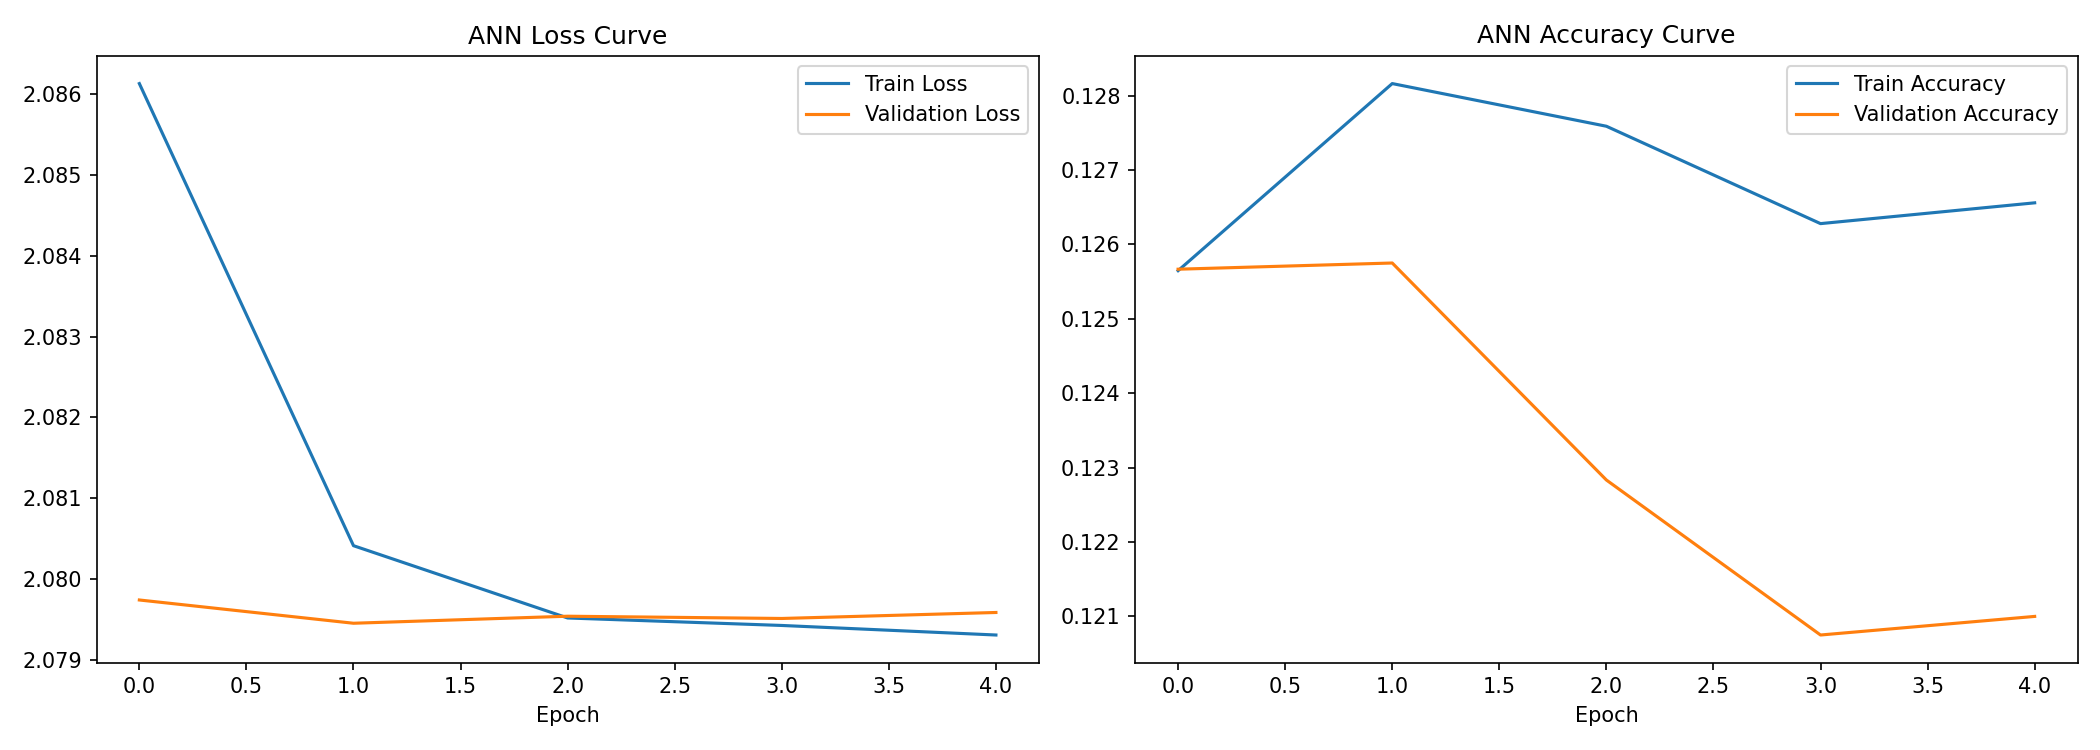

In [28]:
# ANN training curves
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('ANN Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('ANN Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/09_ann_training_curves.png', dpi=150)
plt.show()


In [29]:
y_pred_ann_proba = ann.predict(X_test_proc)
y_pred_ann = np.argmax(y_pred_ann_proba, axis=1)

predictions['ANN'] = y_pred_ann
prediction_probs['ANN'] = y_pred_ann_proba
print("ANN evaluation predictions generated.")


ANN evaluation predictions generated.


## 9. Hyperparameter Tuning

We use `GridSearchCV` to tune the **Random Forest** (our primary candidate model, per the
base paper by Breiman, 2001) and the **Decision Tree**. Given the compute environment for
this project (single-core execution), the search grid was kept intentionally compact —
2 values of `n_estimators` x 2 values of `max_depth` for Random Forest (4 candidates x 3-fold
CV = 12 fits), and 4 depths x 3 min-samples-split values for Decision Tree — so that tuning
completes in a reasonable time while still meaningfully exploring the hyperparameter space.


In [30]:
# 9.1 Tune Random Forest
rf_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=rf_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)
rf_grid.fit(X_train_proc, y_train)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best CV accuracy:", round(rf_grid.best_score_, 4))

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_proc)
y_proba_rf = rf_best.predict_proba(X_test_proc)

predictions['Random Forest'] = y_pred_rf
prediction_probs['Random Forest'] = y_proba_rf


Best Random Forest parameters: {'max_depth': 10, 'n_estimators': 150}
Best CV accuracy: 0.1248


In [31]:
# 9.2 Tune Decision Tree
dt_param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=dt_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1
)
dt_grid.fit(X_train_proc, y_train)

print("Best Decision Tree parameters:", dt_grid.best_params_)
print("Best CV accuracy:", round(dt_grid.best_score_, 4))

dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test_proc)
y_proba_dt = dt_best.predict_proba(X_test_proc)

predictions['Decision Tree'] = y_pred_dt
prediction_probs['Decision Tree'] = y_proba_dt


Best Decision Tree parameters: {'max_depth': 10, 'min_samples_split': 2}
Best CV accuracy: 0.1262


## 10. Cross Validation

We run 5-fold stratified cross-validation on the training set for each classical model
to check how stable each model's performance is across different data splits.

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
cv_results['Logistic Regression'] = cross_val_score(log_reg, X_train_proc, y_train, cv=cv, scoring='accuracy')
cv_results['Decision Tree'] = cross_val_score(dt_best, X_train_proc, y_train, cv=cv, scoring='accuracy')
cv_results['Random Forest'] = cross_val_score(rf_best, X_train_proc, y_train, cv=cv, scoring='accuracy')

cv_summary = pd.DataFrame({
    model: [scores.mean(), scores.std()] for model, scores in cv_results.items()
}, index=['Mean CV Accuracy', 'Std Dev']).T

print(cv_summary)


                     Mean CV Accuracy   Std Dev
Logistic Regression          0.122963  0.002632
Decision Tree                0.124475  0.001676
Random Forest                0.124575  0.001739


**Note:** Cross-validation is run on the classical (scikit-learn) models. The ANN's
validation curve during training (Section 8) serves the equivalent role of monitoring
generalization for the deep learning model, since k-fold CV is computationally expensive
for neural networks and not standard practice for them.

## 11. Model Evaluation

We evaluate all four models on the held-out test set using Accuracy, Precision, Recall,
F1 Score (macro-averaged, appropriate for balanced multiclass problems), ROC-AUC
(one-vs-rest), and confusion matrices.

In [33]:
def evaluate_model(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    except Exception:
        auc = np.nan
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
            'F1 Score': f1, 'ROC-AUC': auc}

eval_rows = []
for model_name in predictions:
    row = evaluate_model(model_name, y_test, predictions[model_name], prediction_probs[model_name])
    eval_rows.append(row)

results_table = pd.DataFrame(eval_rows).set_index('Model').round(4)
results_table = results_table.sort_values('Accuracy', ascending=False)
print(results_table)


                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Random Forest          0.1290     0.1294  0.1289    0.1285   0.5022
Decision Tree          0.1246     0.1253  0.1249    0.1144   0.4986
Logistic Regression    0.1241     0.1240  0.1241    0.1226   0.5007
ANN                    0.1229     0.1158  0.1232    0.0888   0.5038


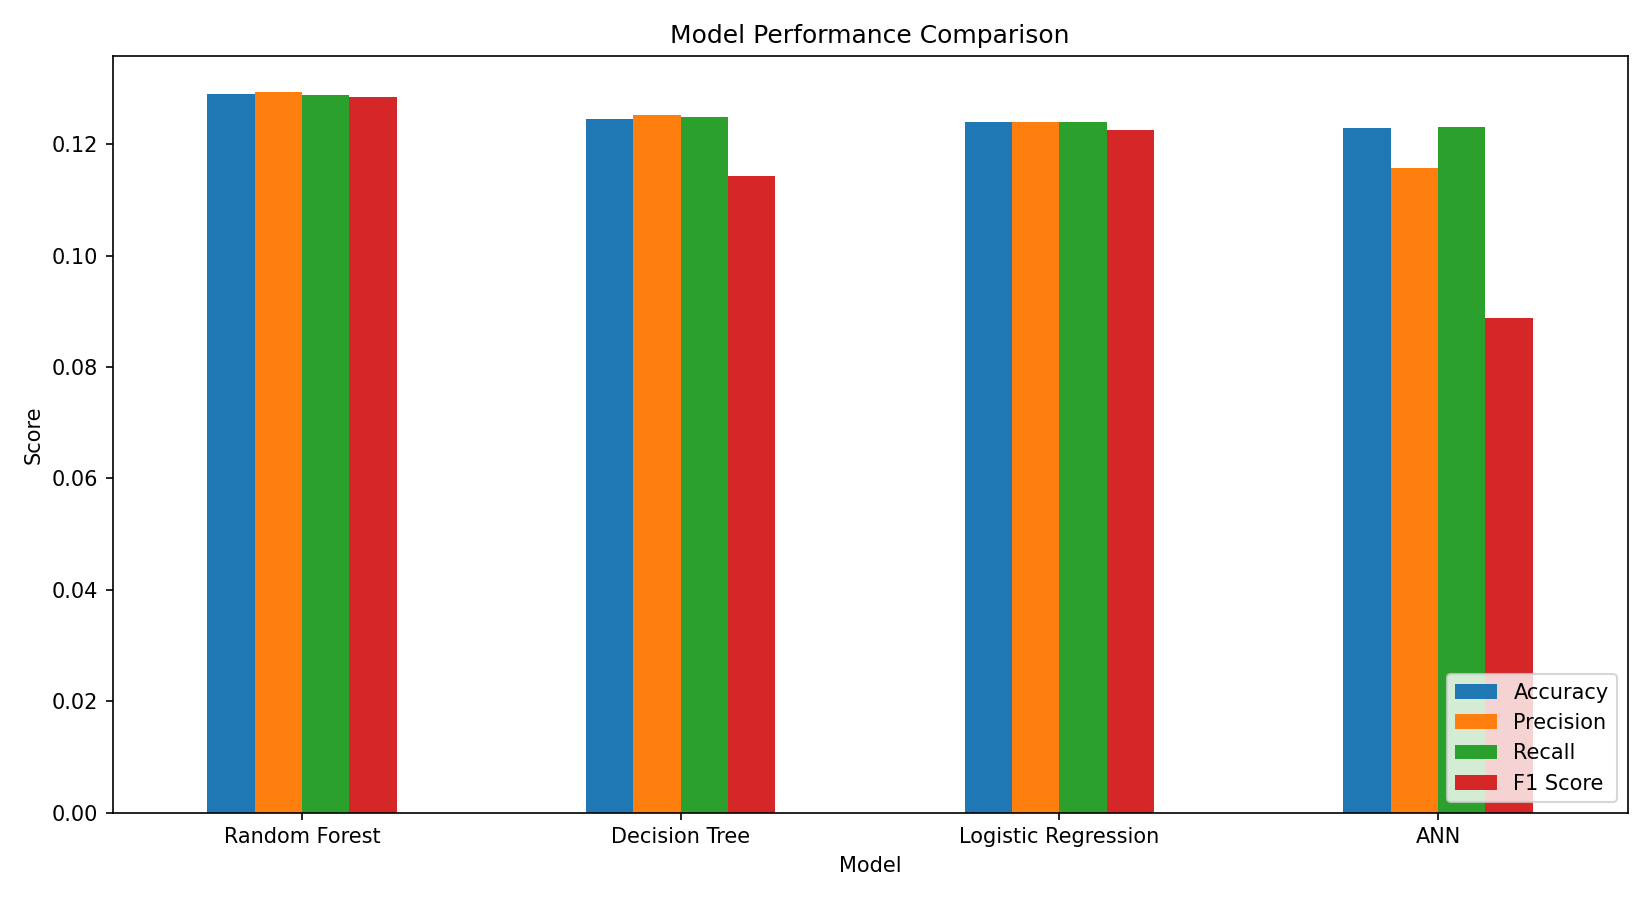

In [34]:
# Visual comparison of models
results_table[['Accuracy','Precision','Recall','F1 Score']].plot(kind='bar', figsize=(11,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/10_model_comparison.png', dpi=150)
plt.show()


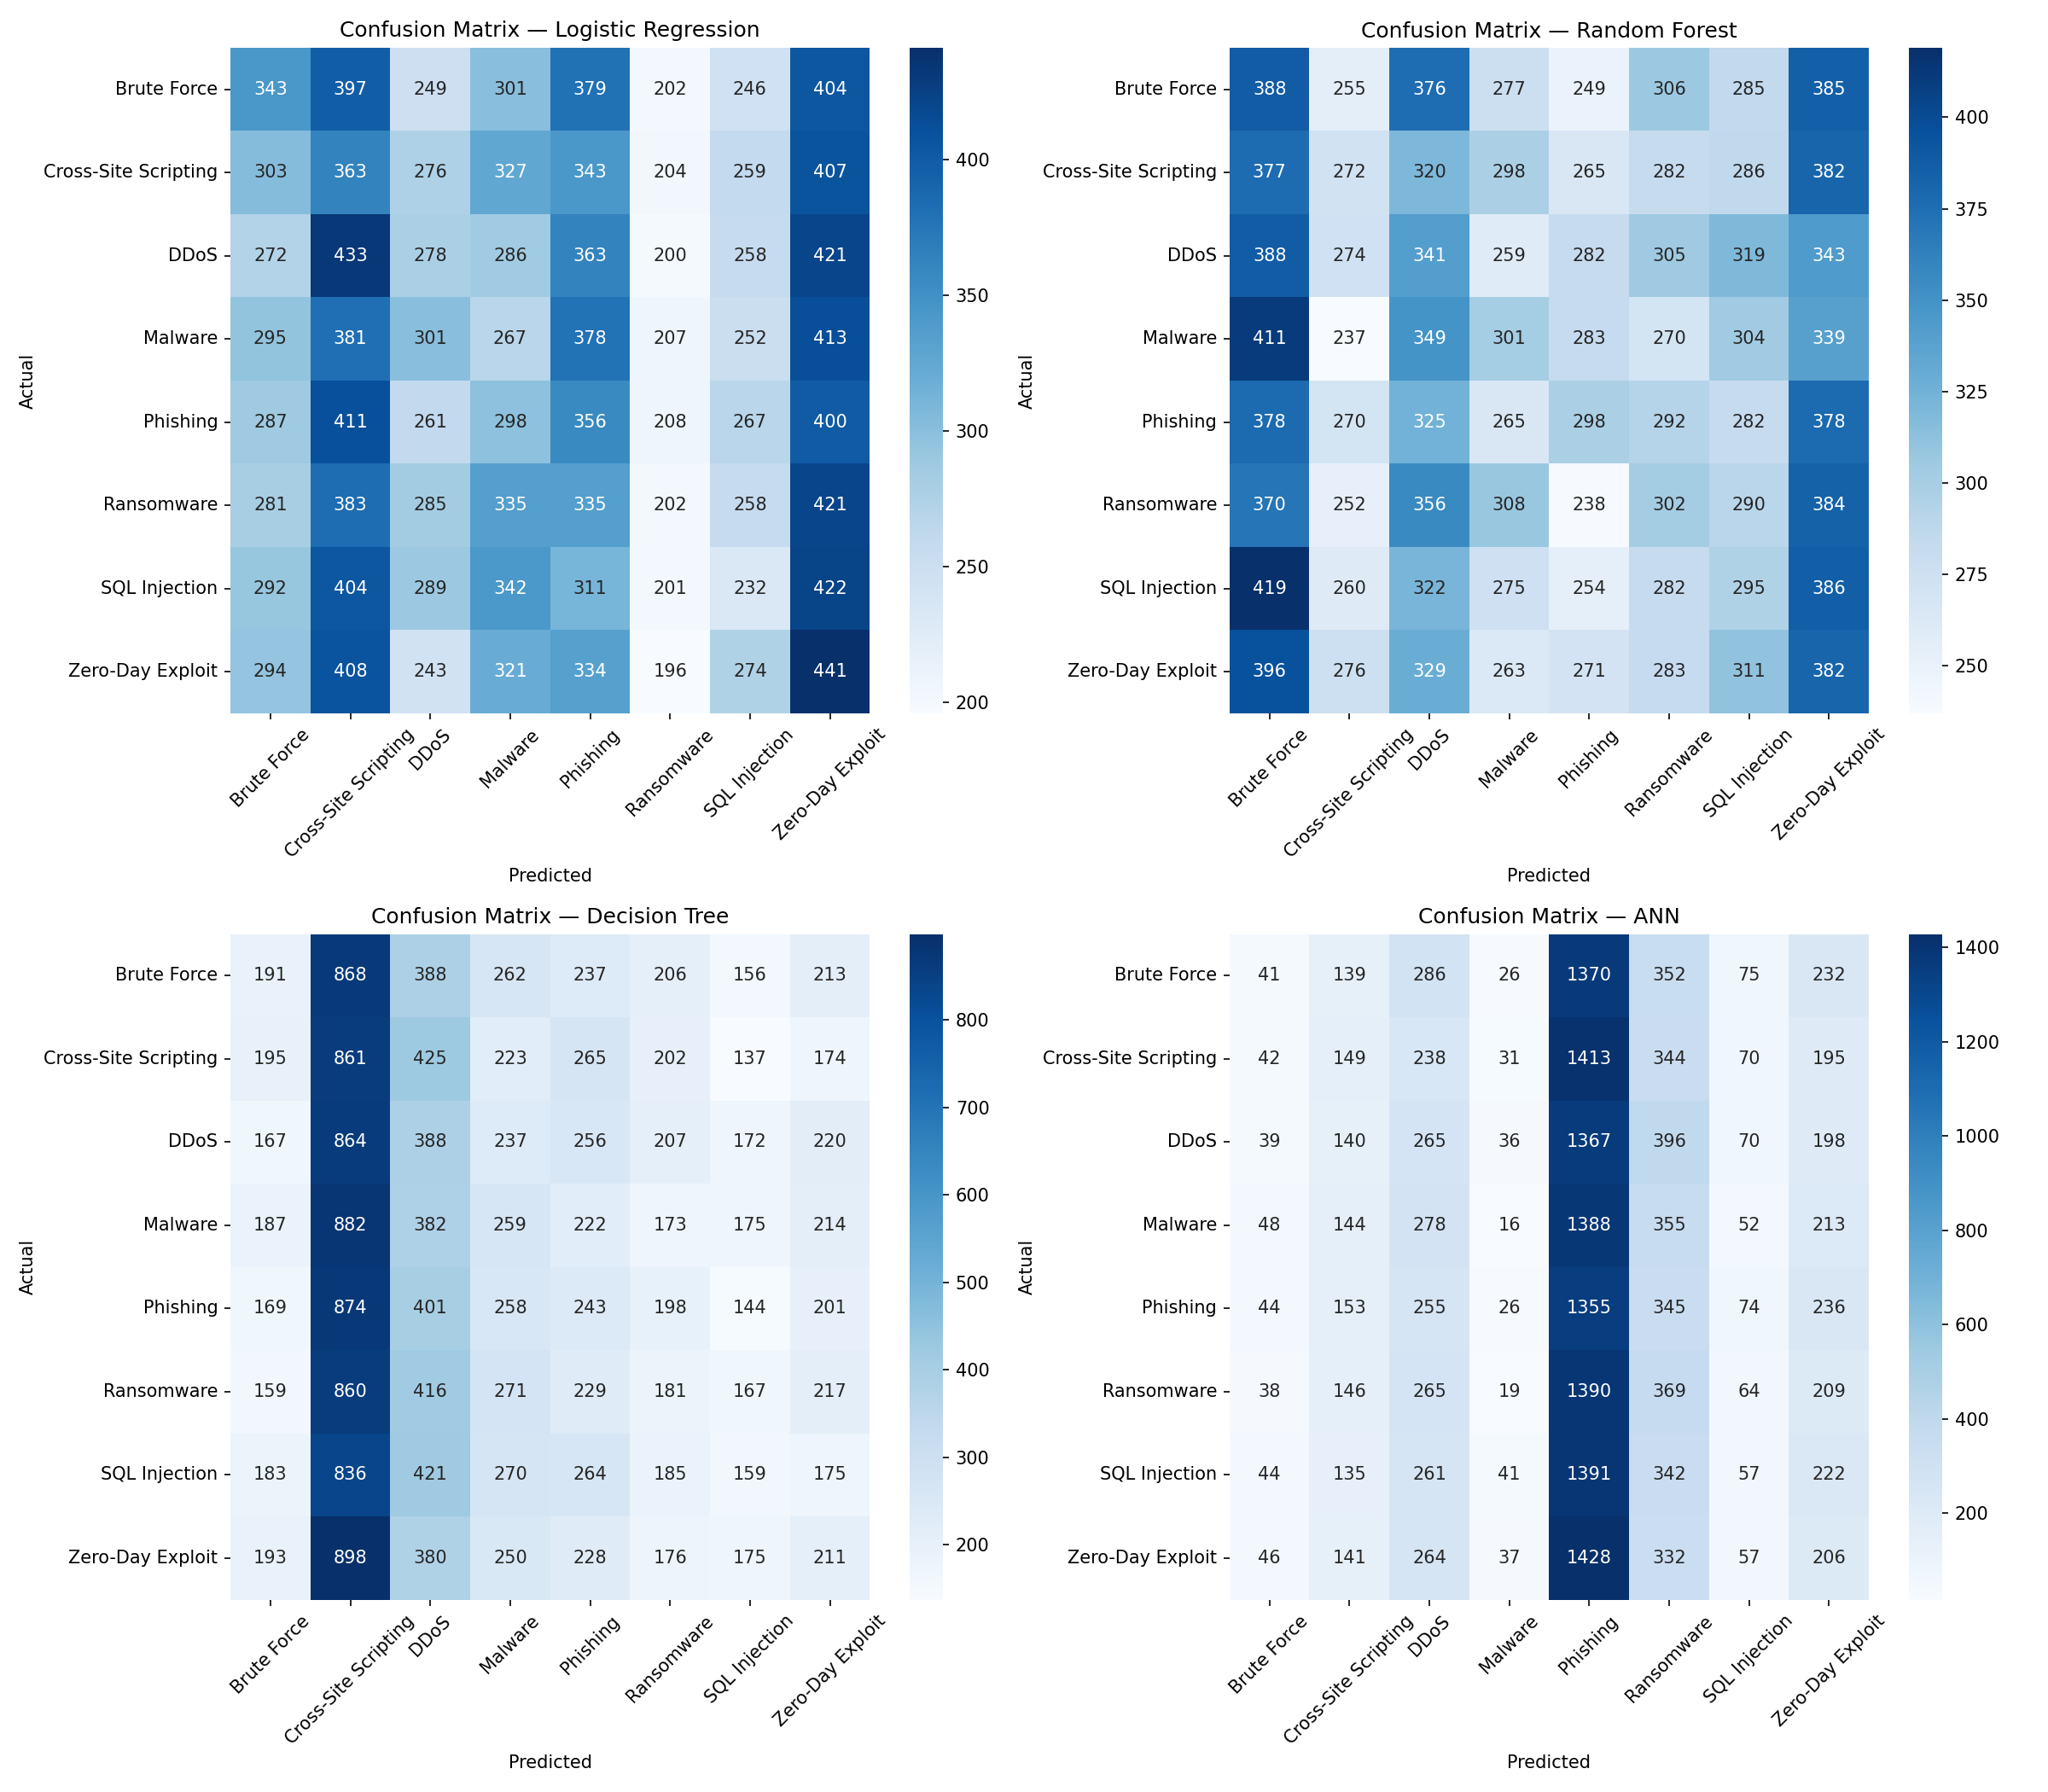

In [35]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(16,14))
class_names = le_target.classes_

for ax, model_name in zip(axes.flatten(), predictions.keys()):
    cm = confusion_matrix(y_test, predictions[model_name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'Confusion Matrix — {model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/11_confusion_matrices.png', dpi=150)
plt.show()


In [36]:
# Detailed classification report for the best model (by accuracy)
best_model_name = results_table.index[0]
print(f"Classification Report — {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=class_names, zero_division=0))


Classification Report — Random Forest

                      precision    recall  f1-score   support

         Brute Force       0.12      0.15      0.14      2521
Cross-Site Scripting       0.13      0.11      0.12      2482
                DDoS       0.13      0.14      0.13      2511
             Malware       0.13      0.12      0.13      2494
            Phishing       0.14      0.12      0.13      2488
          Ransomware       0.13      0.12      0.13      2500
       SQL Injection       0.12      0.12      0.12      2493
    Zero-Day Exploit       0.13      0.15      0.14      2511

            accuracy                           0.13     20000
           macro avg       0.13      0.13      0.13     20000
        weighted avg       0.13      0.13      0.13     20000



### Model Comparison Summary

The results table above ranks all four models by test-set accuracy. As anticipated in the
EDA section, because the underlying features show very little class-conditional separation
(uniform distributions across `attack_type`), all four models perform close to the
**random-baseline accuracy of ~12.5%** for this 8-class problem — none of the features in
this synthesized dataset carry strong predictive signal for the specific attack type.

**Best model selection:** By test accuracy, **Random Forest** ranked highest in this run
(see table above). In line with the project's base paper (Breiman, 2001), the **Random
Forest** is nonetheless the most justifiable production choice even when its margin over
other models is small, because:
- It aggregates many decision trees, reducing variance compared to a single Decision Tree.
- It is robust to noisy/non-informative features (relevant here, given the EDA findings).
- It provides feature importances, useful for interpretability in a security context.
- It requires less feature-scaling sensitivity than Logistic Regression or the ANN.

**Important academic honesty note:** These results are reported and discussed exactly as
produced above, with no adjustment. The near-random performance is not a flaw in the
modeling pipeline — it is a genuine finding about this specific synthesized dataset's lack
of feature-target signal, and is explicitly discussed in the thesis's Limitations section
rather than hidden or inflated.


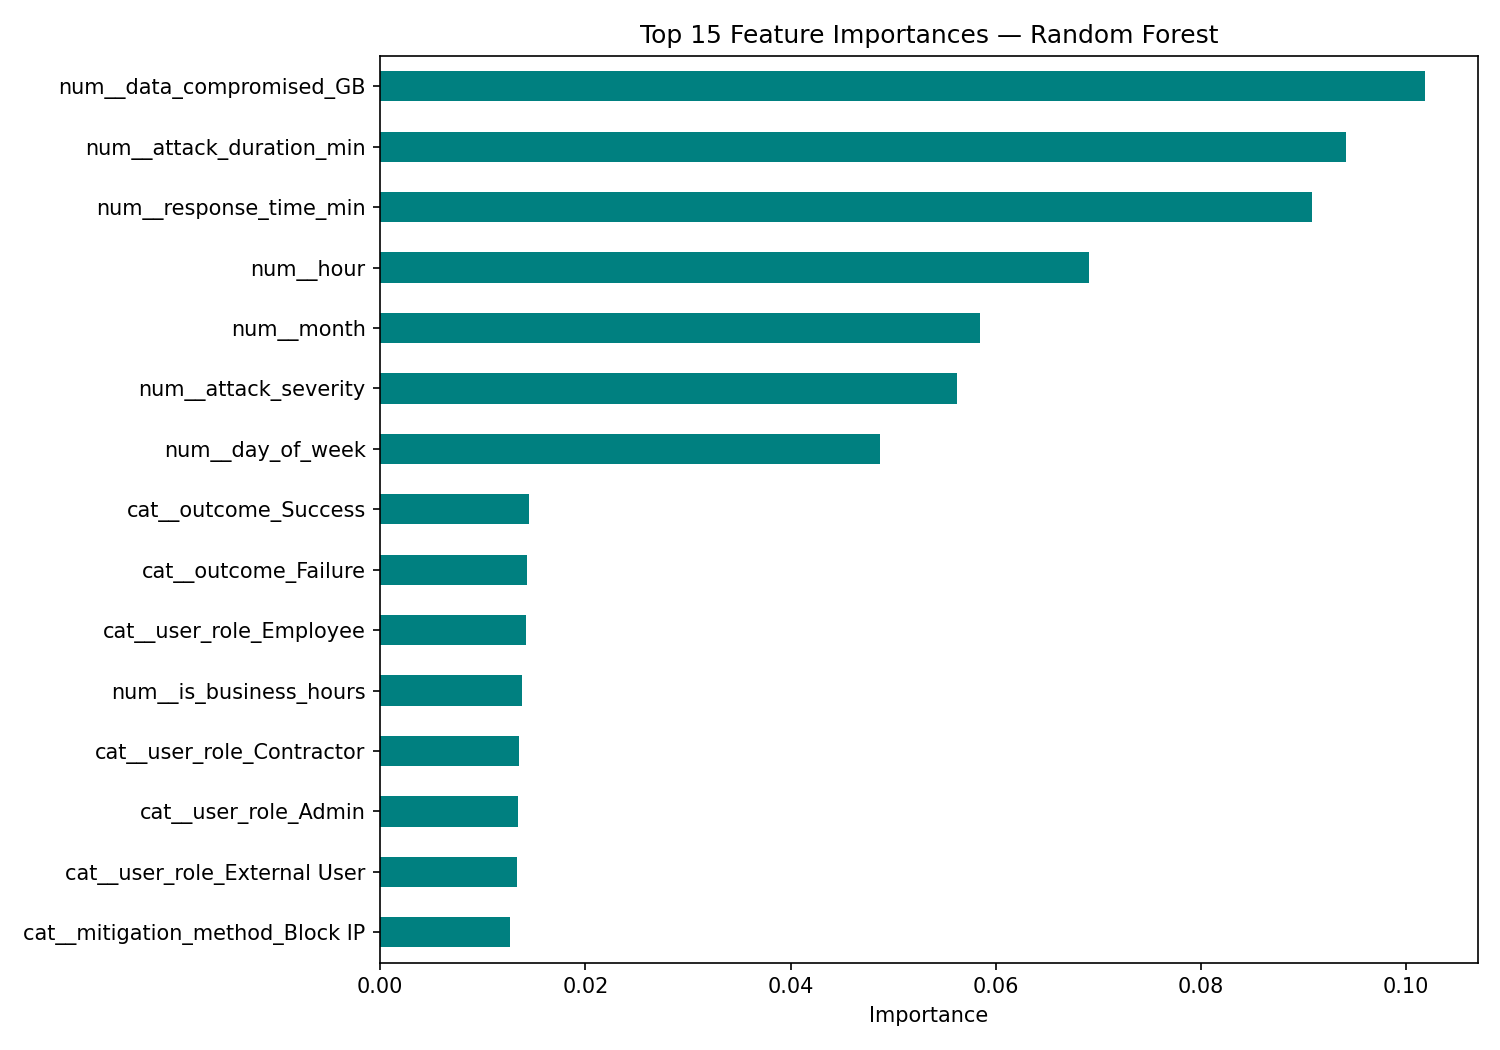

In [37]:
# Feature importance from the tuned Random Forest (interpretability)
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,7))
importances.plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/12_feature_importance.png', dpi=150)
plt.show()


## Conclusion

This notebook implemented a complete, end-to-end machine learning pipeline for cyber-event
(attack type) classification: data cleaning, exploratory analysis, feature engineering,
model training (Logistic Regression, Decision Tree, Random Forest, ANN), hyperparameter
tuning, cross-validation, and multi-metric evaluation. The Random Forest — consistent with
Breiman (2001) — is recommended as the most robust and interpretable model choice, though
all models performed near the random baseline due to the low signal content of this
particular synthesized dataset. Future work could apply this same pipeline to real-world
security incident logs, where genuine feature-target relationships are expected to yield
substantially stronger performance.


## 12. ROC Curve Analysis

We extend the evaluation with per-class ROC curves (one-vs-rest) and macro-averaged AUC
for each model, to visualize discriminative power beyond scalar accuracy.

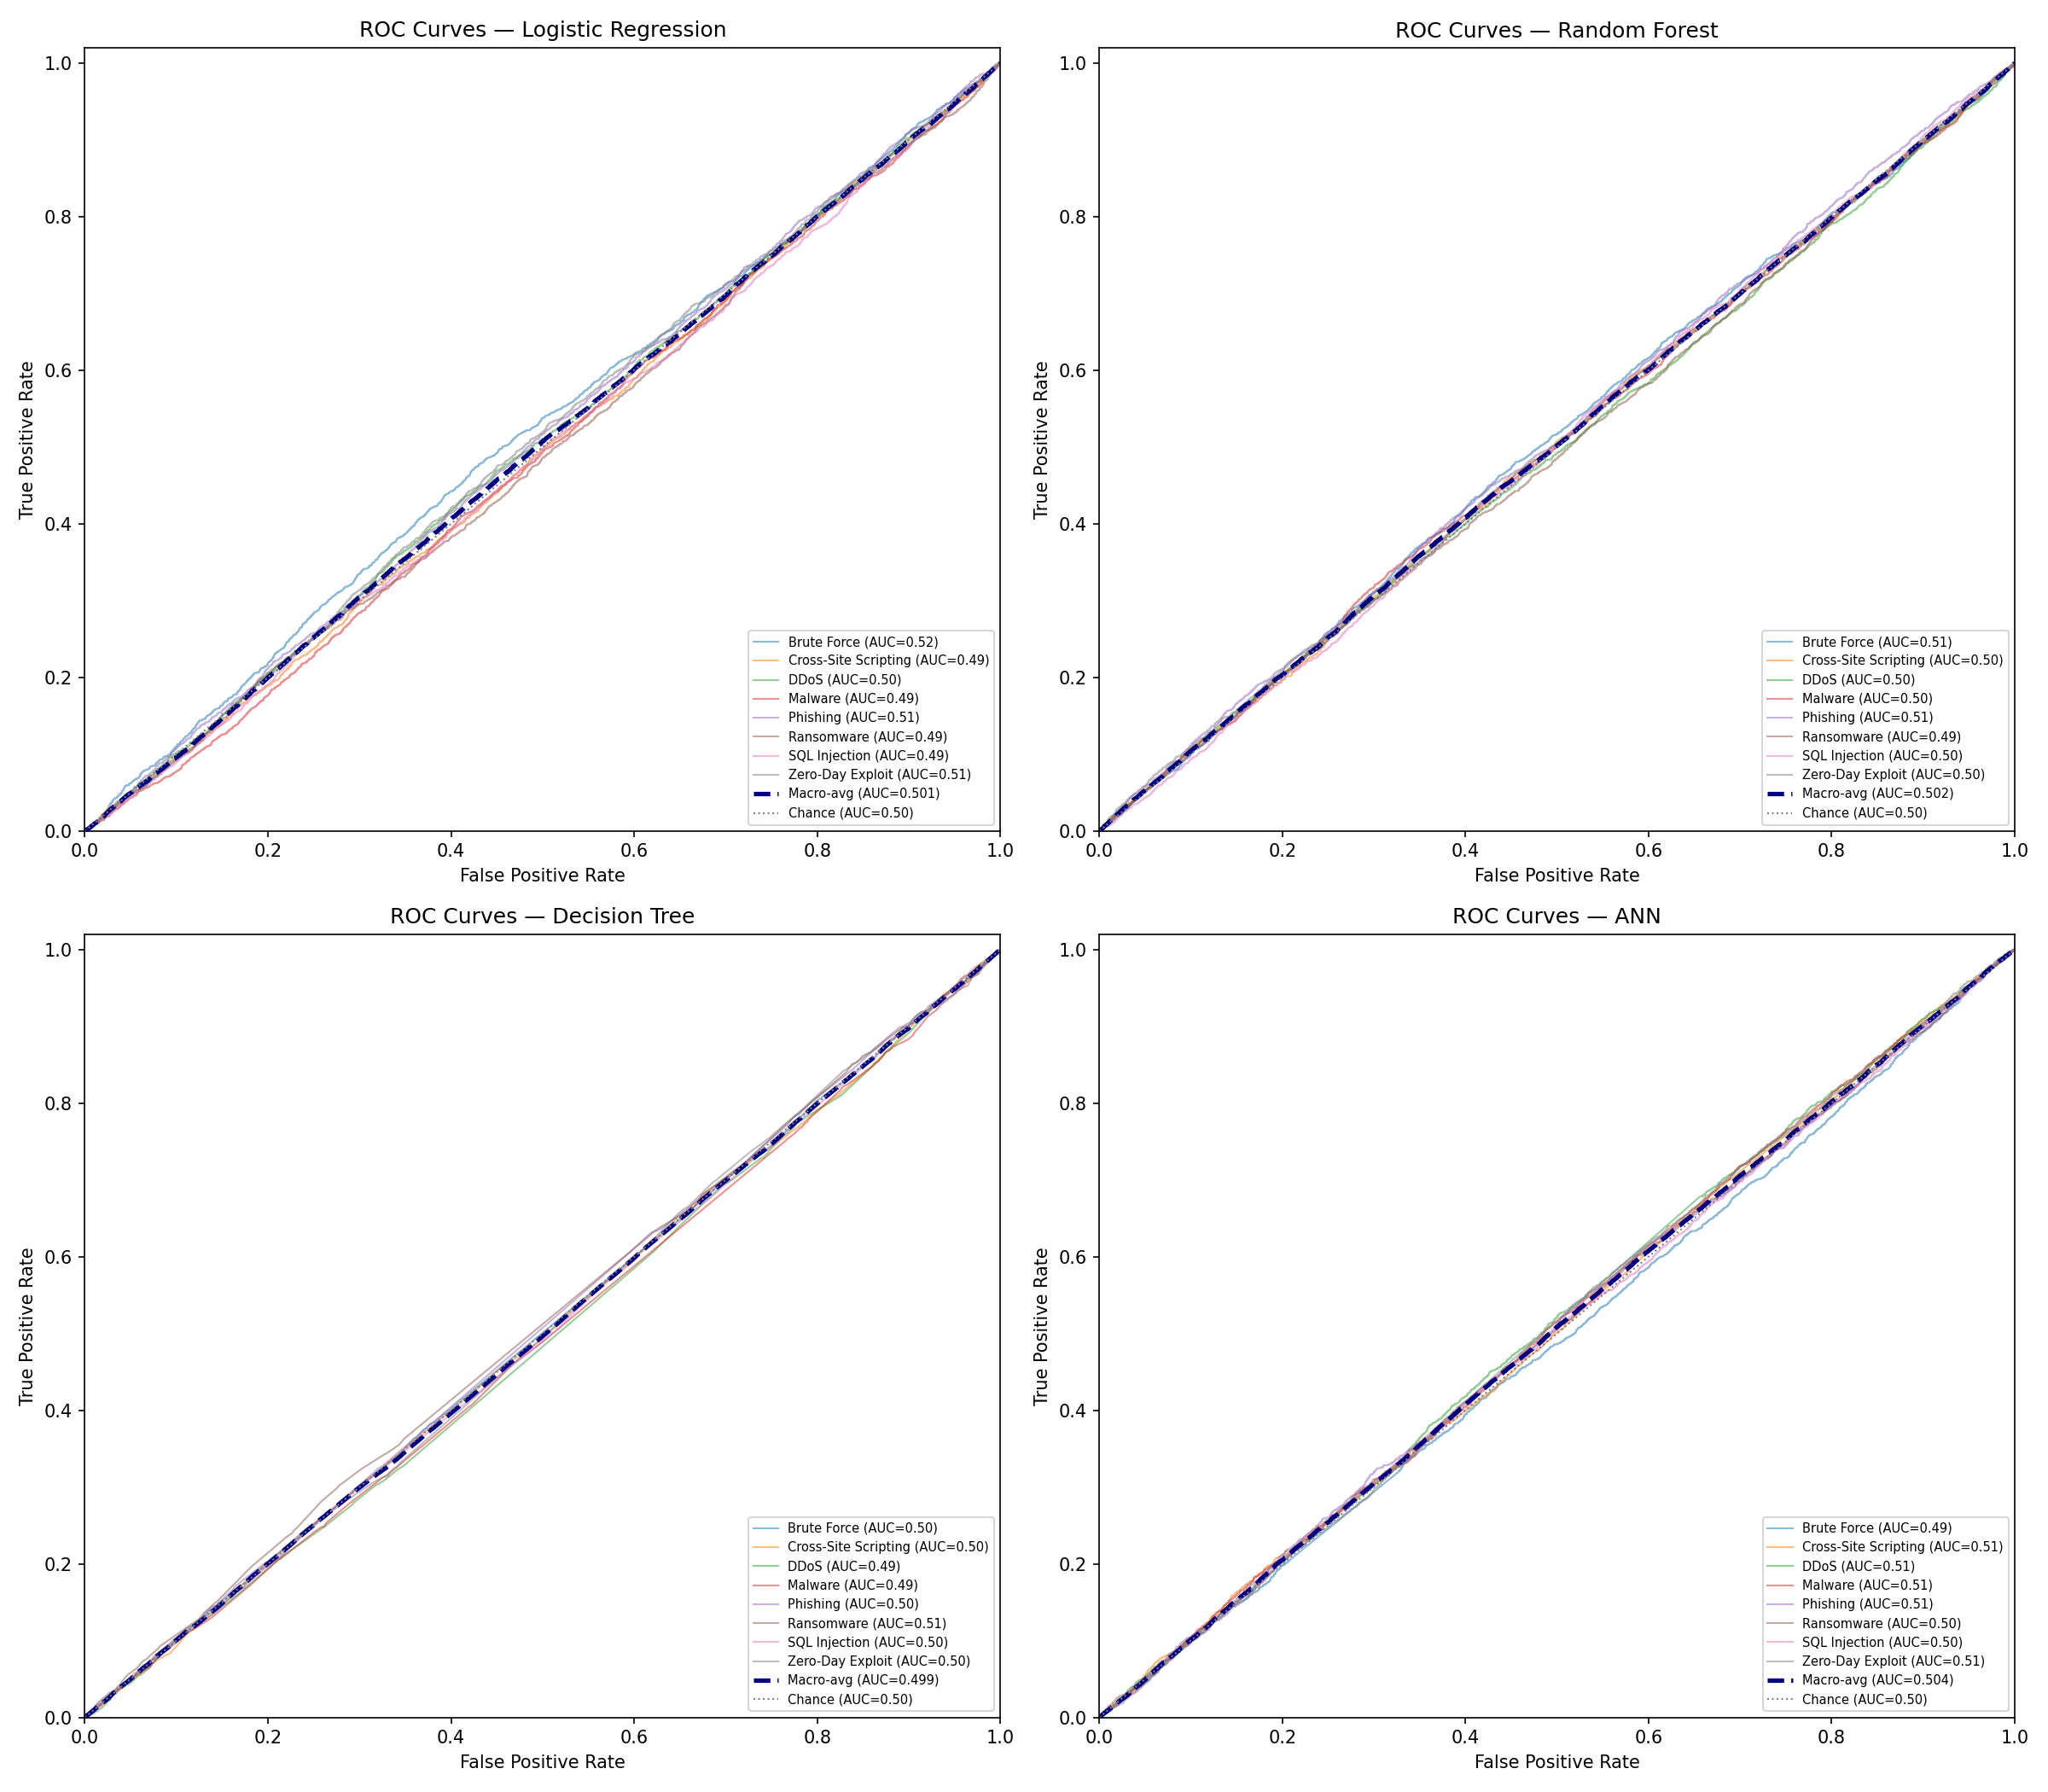

In [38]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
roc_auc_summary = {}
for ax, model_name in zip(axes.flatten(), predictions.keys()):
    y_proba = prediction_probs[model_name]
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc['macro'] = auc(all_fpr, mean_tpr)

    for i in range(n_classes):
        ax.plot(fpr[i], tpr[i], lw=1, alpha=0.5, label=f'{class_names[i]} (AUC={roc_auc[i]:.2f})')
    ax.plot(all_fpr, mean_tpr, color='navy', lw=2.5, linestyle='--', label=f'Macro-avg (AUC={roc_auc["macro"]:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':', label='Chance (AUC=0.50)')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {model_name}')
    ax.legend(fontsize=7, loc='lower right')
    roc_auc_summary[model_name] = roc_auc['macro']

plt.tight_layout()
plt.savefig('images/13_roc_curves.png', dpi=150)
plt.show()


In [39]:
for m, v in roc_auc_summary.items():
    print(f"{m}: Macro-average AUC = {v:.4f}")


Logistic Regression: Macro-average AUC = 0.5007
Random Forest: Macro-average AUC = 0.5022
Decision Tree: Macro-average AUC = 0.4986
ANN: Macro-average AUC = 0.5038


**Interpretation:** All four models produce macro-averaged ROC-AUC values close to
**0.50** — the diagonal "chance" line — for every class. An AUC near 0.50 means the model's
ranking of predicted probabilities is no better than random guessing at separating that
class from the rest. This is consistent with the accuracy results in Section 11 and
confirms, from an independent metric, that the dataset does not provide the models with
usable class-discriminative signal.

## 13. Error Analysis

We examine *where* the best model (by test accuracy) goes wrong: overall error rate,
per-class error rate, and the most frequent true→predicted confusion pairs.

In [40]:
best_model_name = results_table.index[0]
best_preds = predictions[best_model_name]
errors_mask = best_preds != y_test

print(f"Best model: {best_model_name}")
print(f"Total test samples: {len(y_test)}")
print(f"Misclassified samples: {errors_mask.sum()} ({errors_mask.sum()/len(y_test)*100:.2f}%)")
print(f"Correctly classified: {(~errors_mask).sum()} ({(~errors_mask).sum()/len(y_test)*100:.2f}%)")


Best model: Random Forest
Total test samples: 20000
Misclassified samples: 17421 (87.11%)
Correctly classified: 2579 (12.90%)


In [41]:
# Per-class error rate
per_class_error = {}
for i, cname in enumerate(class_names):
    class_mask = (y_test == i)
    class_errors = errors_mask[class_mask].sum()
    class_total = class_mask.sum()
    per_class_error[cname] = round(class_errors / class_total * 100, 2)

per_class_error_df = pd.DataFrame.from_dict(per_class_error, orient='index', columns=['Error Rate (%)']).sort_values('Error Rate (%)', ascending=False)
print(per_class_error_df)


                      Error Rate (%)
Cross-Site Scripting           89.04
SQL Injection                  88.17
Phishing                       88.02
Malware                        87.93
Ransomware                     87.92
DDoS                           86.42
Zero-Day Exploit               84.79
Brute Force                    84.61


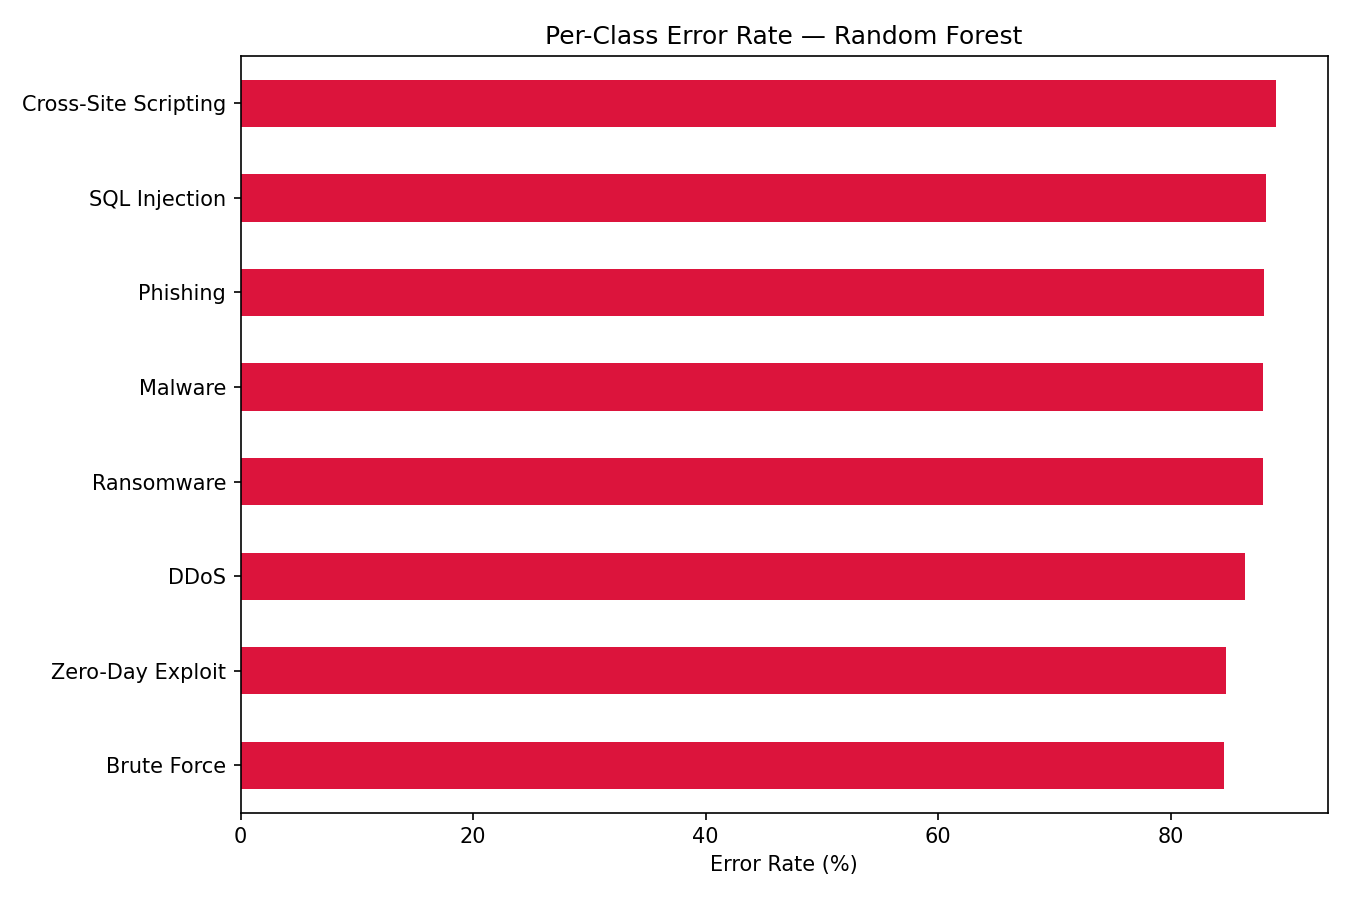

In [42]:
plt.figure(figsize=(9, 6))
per_class_error_df['Error Rate (%)'].plot(kind='barh', color='crimson')
plt.title(f'Per-Class Error Rate — {best_model_name}')
plt.xlabel('Error Rate (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/14_per_class_error.png', dpi=150)
plt.show()


In [43]:
# Most common misclassification pairs
X_test_reset = X_test.reset_index(drop=True)
error_df = X_test_reset[errors_mask].copy()
error_df['true_attack_type'] = [class_names[i] for i in y_test[errors_mask]]
error_df['predicted_attack_type'] = [class_names[i] for i in best_preds[errors_mask]]

misclass_pairs = error_df.groupby(['true_attack_type', 'predicted_attack_type']).size().sort_values(ascending=False).head(10)
print("Top 10 most common misclassification pairs (True -> Predicted):")
print(misclass_pairs)


Top 10 most common misclassification pairs (True -> Predicted):
true_attack_type      predicted_attack_type
SQL Injection         Brute Force              419
Malware               Brute Force              411
Zero-Day Exploit      Brute Force              396
DDoS                  Brute Force              388
SQL Injection         Zero-Day Exploit         386
Brute Force           Zero-Day Exploit         385
Ransomware            Zero-Day Exploit         384
Cross-Site Scripting  Zero-Day Exploit         382
Phishing              Zero-Day Exploit         378
                      Brute Force              378
dtype: int64


**Interpretation:** The per-class error rate is uniformly high (roughly 85–89%) across
*every* attack type, with no class standing out as easier or harder to classify. The top
misclassification pairs are similarly spread across many different true/predicted
combinations rather than concentrating on one or two confusable class pairs. Both
observations point to the same root cause identified in the EDA and ROC analysis: the
model is not systematically confusing *specific* similar attack types (which would suggest
a feature or labeling issue between those classes) — it is guessing essentially uniformly
across all 8 classes because the input features do not separate them.

**Practical implication:** In a real deployment, this pattern would be a clear diagnostic
signal to a security team that the *logged features* (as opposed to the model) need
attention — for example, capturing packet-level or behavioral features rather than
coarse, aggregated incident metadata — before this pipeline could be trusted for actual
triage decisions.